In [1]:
import pandas as pd 
import numpy as np
from pathlib import Path

In [2]:
dataset_path = Path("../dataset/balanceDataset")

In [3]:
healthy_path = dataset_path/"Healthy"

In [4]:
pd_path = dataset_path/"PD"

In [5]:
healthy_files = list(healthy_path.glob("*.csv"))

In [6]:
pd_files = list(pd_path.glob("*.csv"))

In [10]:
len(healthy_files)
len(pd_files)

99

In [11]:
balance_features = [
    "R_Wrist_Acc_X",
    "R_Wrist_Acc_Y",
    "R_Wrist_Acc_Z",
    "R_Wrist_Gyr_X",
    "R_Wrist_Gyr_Y",
    "R_Wrist_Gyr_Z"
]

In [13]:
len(list(pd_path.iterdir()))

101

In [14]:
from collections import Counter

Counter(file.suffix for file in pd_path.iterdir())

Counter({'.csv': 99, '.py': 1, '': 1})

In [15]:
def extract_feature(df, feature_cols):
    features = {}
    for col in feature_cols:
        signal = pd.to_numeric(
            df[col],
            errors="coerce"
        ).dropna()
        features[f"{col}_mean"] = signal.mean()
        features[f"{col}_std"] = signal.std()
        features[f"{col}_min"] = signal.min()
        features[f"{col}_max"] = signal.max()
        features[f"{col}_rms"] = np.sqrt(np.mean(signal ** 2))

    return features

In [16]:
df = pd.read_csv(
    healthy_files[0],
    usecols=balance_features
)

In [17]:
features = extract_feature(df, balance_features)

In [18]:
print("Number of features", len(features))

Number of features 30


In [22]:
pd.Series(features)

R_Wrist_Acc_X_mean     8.508500
R_Wrist_Acc_X_std      0.645525
R_Wrist_Acc_X_min      4.533342
R_Wrist_Acc_X_max     12.769121
R_Wrist_Acc_X_rms      8.532950
R_Wrist_Acc_Y_mean    -4.677607
R_Wrist_Acc_Y_std      1.031779
R_Wrist_Acc_Y_min    -13.657603
R_Wrist_Acc_Y_max     10.638203
R_Wrist_Acc_Y_rms      4.790037
R_Wrist_Acc_Z_mean     1.108345
R_Wrist_Acc_Z_std      0.726602
R_Wrist_Acc_Z_min     -9.121718
R_Wrist_Acc_Z_max      9.304117
R_Wrist_Acc_Z_rms      1.325263
R_Wrist_Gyr_X_mean    -0.007013
R_Wrist_Gyr_X_std      0.614827
R_Wrist_Gyr_X_min    -13.942029
R_Wrist_Gyr_X_max      9.899535
R_Wrist_Gyr_X_rms      0.614833
R_Wrist_Gyr_Y_mean     0.003958
R_Wrist_Gyr_Y_std      0.235201
R_Wrist_Gyr_Y_min     -1.145073
R_Wrist_Gyr_Y_max      3.787190
R_Wrist_Gyr_Y_rms      0.235222
R_Wrist_Gyr_Z_mean    -0.005864
R_Wrist_Gyr_Z_std      0.132744
R_Wrist_Gyr_Z_min     -0.867109
R_Wrist_Gyr_Z_max      0.931218
R_Wrist_Gyr_Z_rms      0.132867
dtype: float64

ValueError: Usecols do not match columns, columns expected but not found: ['R_Wrist_Acc_Y', 'R_Wrist_Gyr_Z', 'R_Wrist_Acc_X', 'R_Wrist_Acc_Z', 'R_Wrist_Gyr_X', 'R_Wrist_Gyr_Y']

In [24]:
test_df = pd.read_csv(healthy_files[0])

print([repr(col) for col in test_df.columns if "Wrist" in col])

["'R_Wrist_Acc_X'", "'R_Wrist_Acc_Y'", "'R_Wrist_Acc_Z'", "'R_Wrist_FreeAcc_E'", "'R_Wrist_FreeAcc_N'", "'R_Wrist_FreeAcc_U'", "'R_Wrist_Gyr_X'", "'R_Wrist_Gyr_Y'", "'R_Wrist_Gyr_Z'", "'R_Wrist_Mag_X'", "'R_Wrist_Mag_Y'", "'R_Wrist_Mag_Z'", "'R_Wrist_VelInc_X'", "'R_Wrist_VelInc_Y'", "'R_Wrist_VelInc_Z'", "'R_Wrist_OriInc_q0'", "'R_Wrist_OriInc_q1'", "'R_Wrist_OriInc_q2'", "'R_Wrist_OriInc_q3'", "'R_Wrist_Roll'", "'R_Wrist_Pitch'", "'R_Wrist_Yaw'", "'L_Wrist_Acc_X'", "'L_Wrist_Acc_Y'", "'L_Wrist_Acc_Z'", "'L_Wrist_FreeAcc_E'", "'L_Wrist_FreeAcc_N'", "'L_Wrist_FreeAcc_U'", "'L_Wrist_Gyr_X'", "'L_Wrist_Gyr_Y'", "'L_Wrist_Gyr_Z'", "'L_Wrist_Mag_X'", "'L_Wrist_Mag_Y'", "'L_Wrist_Mag_Z'", "'L_Wrist_VelInc_X'", "'L_Wrist_VelInc_Y'", "'L_Wrist_VelInc_Z'", "'L_Wrist_OriInc_q0'", "'L_Wrist_OriInc_q1'", "'L_Wrist_OriInc_q2'", "'L_Wrist_OriInc_q3'", "'L_Wrist_Roll'", "'L_Wrist_Pitch'", "'L_Wrist_Yaw'"]


In [25]:
print([repr(col) for col in balance_features])

["'R_Wrist_Acc_X'", "'R_Wrist_Acc_Y'", "'R_Wrist_Acc_Z'", "'R_Wrist_Gyr_X'", "'R_Wrist_Gyr_Y'", "'R_Wrist_Gyr_Z'"]


In [26]:
test_df = pd.read_csv(healthy_files[0])

print([repr(col) for col in test_df.columns[:20]])

["'Time'", "'GeneralEvent'", "'ClinicalEvent'", "'L Foot Contact'", "'R Foot Contact'", "'L Foot Pressure'", "'R Foot Pressure'", "'Walkway_X'", "'Walkway_Y'", "'WalkwayPressureLevel'", "'WalkwayFoot'", "'LowerBack_Acc_X'", "'LowerBack_Acc_Y'", "'LowerBack_Acc_Z'", "'LowerBack_FreeAcc_E'", "'LowerBack_FreeAcc_N'", "'LowerBack_FreeAcc_U'", "'LowerBack_Gyr_X'", "'LowerBack_Gyr_Y'", "'LowerBack_Gyr_Z'"]


In [27]:
print([repr(col) for col in test_df.columns if "Wrist" in col])

["'R_Wrist_Acc_X'", "'R_Wrist_Acc_Y'", "'R_Wrist_Acc_Z'", "'R_Wrist_FreeAcc_E'", "'R_Wrist_FreeAcc_N'", "'R_Wrist_FreeAcc_U'", "'R_Wrist_Gyr_X'", "'R_Wrist_Gyr_Y'", "'R_Wrist_Gyr_Z'", "'R_Wrist_Mag_X'", "'R_Wrist_Mag_Y'", "'R_Wrist_Mag_Z'", "'R_Wrist_VelInc_X'", "'R_Wrist_VelInc_Y'", "'R_Wrist_VelInc_Z'", "'R_Wrist_OriInc_q0'", "'R_Wrist_OriInc_q1'", "'R_Wrist_OriInc_q2'", "'R_Wrist_OriInc_q3'", "'R_Wrist_Roll'", "'R_Wrist_Pitch'", "'R_Wrist_Yaw'", "'L_Wrist_Acc_X'", "'L_Wrist_Acc_Y'", "'L_Wrist_Acc_Z'", "'L_Wrist_FreeAcc_E'", "'L_Wrist_FreeAcc_N'", "'L_Wrist_FreeAcc_U'", "'L_Wrist_Gyr_X'", "'L_Wrist_Gyr_Y'", "'L_Wrist_Gyr_Z'", "'L_Wrist_Mag_X'", "'L_Wrist_Mag_Y'", "'L_Wrist_Mag_Z'", "'L_Wrist_VelInc_X'", "'L_Wrist_VelInc_Y'", "'L_Wrist_VelInc_Z'", "'L_Wrist_OriInc_q0'", "'L_Wrist_OriInc_q1'", "'L_Wrist_OriInc_q2'", "'L_Wrist_OriInc_q3'", "'L_Wrist_Roll'", "'L_Wrist_Pitch'", "'L_Wrist_Yaw'"]


In [28]:
print(balance_features == [
    col for col in test_df.columns
    if col in balance_features
])

True


In [29]:
for file in healthy_files:
    df_test = pd.read_csv(file, nrows=1)

    missing = [col for col in balance_features if col not in df_test.columns]

    if missing:
        print("Problem file:", file.name)
        print("Missing:", missing)

Problem file: HC139_Balance.csv
Missing: ['R_Wrist_Acc_X', 'R_Wrist_Acc_Y', 'R_Wrist_Acc_Z', 'R_Wrist_Gyr_X', 'R_Wrist_Gyr_Y', 'R_Wrist_Gyr_Z']


In [30]:
problem_file = healthy_path / "HC139_Balance.csv"

problem_df = pd.read_csv(problem_file, nrows=1)

print(problem_df.shape)
print([col for col in problem_df.columns if "Wrist" in col])

(1, 61)
[]


In [31]:
print(problem_df.columns.tolist())

['Time', 'GeneralEvent', 'ClinicalEvent', 'L Foot Contact', 'R Foot Contact', 'L Foot Pressure', 'R Foot Pressure', 'Walkway_X', 'Walkway_Y', 'WalkwayPressureLevel', 'WalkwayFoot', 'LPressure1', 'LPressure2', 'LPressure3', 'LPressure4', 'LPressure5', 'LPressure6', 'LPressure7', 'LPressure8', 'LPressure9', 'LPressure10', 'LPressure11', 'LPressure12', 'LPressure13', 'LPressure14', 'LPressure15', 'LPressure16', 'Linsole:Acc_X', 'Linsole:Acc_Y', 'Linsole:Acc_Z', 'Linsole:Gyr_X', 'Linsole:Gyr_Y', 'Linsole:Gyr_Z', 'LTotalForce', 'LCoP_X', 'LCoP_Y', 'RPressure1', 'RPressure2', 'RPressure3', 'RPressure4', 'RPressure5', 'RPressure6', 'RPressure7', 'RPressure8', 'RPressure9', 'RPressure10', 'RPressure11', 'RPressure12', 'RPressure13', 'RPressure14', 'RPressure15', 'RPressure16', 'Rinsole:Acc_X', 'Rinsole:Acc_Y', 'Rinsole:Acc_Z', 'Rinsole:Gyr_X', 'Rinsole:Gyr_Y', 'Rinsole:Gyr_Z', 'RTotalForce', 'RCoP_X', 'RCoP_Y']


In [32]:
for file in pd_files:
    df_test = pd.read_csv(file, nrows=1)

    missing = [
        col for col in balance_features
        if col not in df_test.columns
    ]

    if missing:
        print("Problem file:", file.name)
        print("Missing:", missing)

In [33]:
usable_healthy_files = [
    file for file in healthy_files
    if file.name != "HC139_Balance.csv"
]

usable_pd_files = pd_files.copy()

print("Usable Healthy:", len(usable_healthy_files))
print("Usable PD:", len(usable_pd_files))
print("Total:", len(usable_healthy_files) + len(usable_pd_files))

Usable Healthy: 84
Usable PD: 99
Total: 183


In [34]:
print("Excluded Healthy:", set(healthy_files) - set(usable_healthy_files))

Excluded Healthy: {PosixPath('../dataset/balanceDataset/Healthy/HC139_Balance.csv')}


In [ ]:
x_data = []
y_data = []
for file in usable_healthy_files:
    df = pd.read_csv(file, usecols=balance_features)
    features = extract_feature(df, balance_features)
    x_data.append(features)
    y_data.append(0)


for file in pd_files:
    df = pd.read_csv(file, usecols=balance_features)
    features = extract_feature(df, balance_features)
    x_data.append(features)
    y_data.append(1)


In [38]:
len(x_data)

183

In [41]:
X= pd.DataFrame(x_data)
Y= pd.Series(y_data, name = "label")

In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (183, 30)
y shape: (183,)


In [43]:
Y.value_counts()

label
1    99
0    84
Name: count, dtype: int64

In [45]:
print("NaN values:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X).sum().sum())

NaN values: 0
Infinite values: 0


In [46]:
X.head()

,R_Wrist_Acc_X_mean,R_Wrist_Acc_X_std,R_Wrist_Acc_X_min,R_Wrist_Acc_X_max,R_Wrist_Acc_X_rms,R_Wrist_Acc_Y_mean,R_Wrist_Acc_Y_std,R_Wrist_Acc_Y_min,R_Wrist_Acc_Y_max,R_Wrist_Acc_Y_rms,...,R_Wrist_Gyr_Y_mean,R_Wrist_Gyr_Y_std,R_Wrist_Gyr_Y_min,R_Wrist_Gyr_Y_max,R_Wrist_Gyr_Y_rms,R_Wrist_Gyr_Z_mean,R_Wrist_Gyr_Z_std,R_Wrist_Gyr_Z_min,R_Wrist_Gyr_Z_max,R_Wrist_Gyr_Z_rms
0,8.508500,0.645525,4.533342,12.769121,8.532950,-4.677607,1.031779,-13.657603,10.638203,4.790037,...,0.003958,0.235201,-1.145073,3.787190,0.235222,-0.005864,0.132744,-0.867109,0.931218,0.132867
1,8.396225,1.599366,-1.378446,32.755812,8.547189,-3.524444,1.676582,-28.634194,5.650275,3.902884,...,-0.008718,0.285327,-2.932958,1.922116,0.285454,0.013698,0.280095,-2.181415,3.386841,0.280423
2,7.411744,2.011667,-1.844466,11.691663,7.679878,-3.356350,1.339286,-21.252317,2.076843,3.613678,...,-0.001024,0.330237,-3.161945,2.933092,0.330229,-0.002012,0.308240,-2.113644,2.262853,0.308238
3,9.435827,0.553747,5.852739,12.874154,9.452061,-2.518468,1.124381,-9.993211,3.985975,2.758048,...,-0.003615,0.224559,-2.087209,1.263329,0.224580,-0.003479,0.179279,-1.496474,2.426133,0.179306
4,9.512989,0.471613,5.944484,13.671441,9.524671,-1.076516,0.655576,-3.851947,3.993043,1.260407,...,-0.000270,0.142732,-1.119918,0.962253,0.142725,-0.002935,0.182588,-1.087225,1.322963,0.182603


In [48]:
print("X shape:", X.shape)
print("NaN:", X.isnull().sum().sum())
print("Inf:", np.isinf(X).sum().sum())

X shape: (183, 30)
NaN: 0
Inf: 0


In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, 
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [52]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

X_train: (146, 30)
X_test : (37, 30)
Y_train: (146,)
Y_test : (37,)


In [53]:
print("Train:")
print(Y_train.value_counts())

print("\nTest:")
print(Y_test.value_counts())

Train:
label
1    79
0    67
Name: count, dtype: int64

Test:
label
1    20
0    17
Name: count, dtype: int64


In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
model = RandomForestClassifier(
    n_estimators= 200,
    random_state=42
)

In [56]:
model.fit(X_train, Y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = model.predict(X_test)

In [58]:
y_pred

array([1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1])

In [59]:
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

In [62]:
print("Accuracy :", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall   :", recall_score(Y_test, y_pred))
print("F1 Score :", f1_score(Y_test, y_pred))

Accuracy : 0.5675675675675675
Precision: 0.6
Recall   : 0.6
F1 Score : 0.6


In [63]:
cm = confusion_matrix(Y_test, y_pred)

In [64]:
print(cm)

[[ 9  8]
 [ 8 12]]


In [66]:
print(classification_report(
    Y_test,
    y_pred,
    target_names=["Healthy", "PD"]
))

              precision    recall  f1-score   support

     Healthy       0.53      0.53      0.53        17
          PD       0.60      0.60      0.60        20

    accuracy                           0.57        37
   macro avg       0.56      0.56      0.56        37
weighted avg       0.57      0.57      0.57        37



In [67]:
def extract_balance_features(df, feature_cols):
    features = {}

    # Convert to numeric
    df = df[feature_cols].apply(pd.to_numeric, errors="coerce")

    # Individual signals
    for col in feature_cols:
        signal = df[col].dropna()

        features[f"{col}_mean"] = signal.mean()
        features[f"{col}_std"] = signal.std()
        features[f"{col}_min"] = signal.min()
        features[f"{col}_max"] = signal.max()
        features[f"{col}_rms"] = np.sqrt(np.mean(signal ** 2))

    # Overall acceleration magnitude
    acc_mag = np.sqrt(
        df["R_Wrist_Acc_X"]**2 +
        df["R_Wrist_Acc_Y"]**2 +
        df["R_Wrist_Acc_Z"]**2
    )

    # Overall gyroscope magnitude
    gyr_mag = np.sqrt(
        df["R_Wrist_Gyr_X"]**2 +
        df["R_Wrist_Gyr_Y"]**2 +
        df["R_Wrist_Gyr_Z"]**2
    )

    # Magnitude statistics
    for name, signal in [
        ("Acc_Magnitude", acc_mag),
        ("Gyr_Magnitude", gyr_mag)
    ]:
        signal = signal.dropna()

        features[f"{name}_mean"] = signal.mean()
        features[f"{name}_std"] = signal.std()
        features[f"{name}_min"] = signal.min()
        features[f"{name}_max"] = signal.max()
        features[f"{name}_rms"] = np.sqrt(np.mean(signal ** 2))

    return features

In [68]:
df = pd.read_csv(
    usable_healthy_files[0],
    usecols=balance_features
)

features = extract_balance_features(df, balance_features)

print("Number of features:", len(features))

Number of features: 40


In [69]:
X_data = []
y_data = []

for file in usable_healthy_files:
    df = pd.read_csv(file, usecols=balance_features)

    features = extract_balance_features(df, balance_features)

    X_data.append(features)
    y_data.append(0)


for file in usable_pd_files:
    df = pd.read_csv(file, usecols=balance_features)

    features = extract_balance_features(df, balance_features)

    X_data.append(features)
    y_data.append(1)

In [70]:
X = pd.DataFrame(X_data)
y = pd.Series(y_data, name="label")

print(X.shape)
print(y.shape)

(183, 40)
(183,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [73]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5135135135135135
Precision: 0.5555555555555556
Recall   : 0.5
F1 Score : 0.5263157894736842


In [74]:
X_with_label = X.copy()
X_with_label["label"] = y

X_with_label.groupby("label").mean().T

label,0,1
R_Wrist_Acc_X_mean,8.762722,8.594204
R_Wrist_Acc_X_std,1.618159,1.488842
R_Wrist_Acc_X_min,-2.824843,-2.093979
R_Wrist_Acc_X_max,20.051198,19.140712
R_Wrist_Acc_X_rms,8.983236,8.965861
R_Wrist_Acc_Y_mean,-2.206191,-2.648988
R_Wrist_Acc_Y_std,1.459901,1.525013
R_Wrist_Acc_Y_min,-18.196809,-15.674035
R_Wrist_Acc_Y_max,10.759513,10.797737
R_Wrist_Acc_Y_rms,2.790417,3.237513


In [75]:
X_with_label.groupby("label").std().T

label,0,1
R_Wrist_Acc_X_mean,0.919729,1.930178
R_Wrist_Acc_X_std,1.043133,1.173609
R_Wrist_Acc_X_min,7.356907,9.974617
R_Wrist_Acc_X_max,11.112315,12.186116
R_Wrist_Acc_X_rms,0.789549,0.865476
R_Wrist_Acc_Y_mean,1.286017,1.473881
R_Wrist_Acc_Y_std,0.662837,0.891708
R_Wrist_Acc_Y_min,14.999573,9.525805
R_Wrist_Acc_Y_max,10.112009,13.499136
R_Wrist_Acc_Y_rms,1.138280,1.347938


In [76]:
import matplotlib.pyplot as plt

healthy_df = pd.read_csv(
    usable_healthy_files[0],
    usecols=balance_features
)

pd_df = pd.read_csv(
    usable_pd_files[0],
    usecols=balance_features
)

healthy_gyr = np.sqrt(
    healthy_df["R_Wrist_Gyr_X"]**2 +
    healthy_df["R_Wrist_Gyr_Y"]**2 +
    healthy_df["R_Wrist_Gyr_Z"]**2
)

pd_gyr = np.sqrt(
    pd_df["R_Wrist_Gyr_X"]**2 +
    pd_df["R_Wrist_Gyr_Y"]**2 +
    pd_df["R_Wrist_Gyr_Z"]**2
)

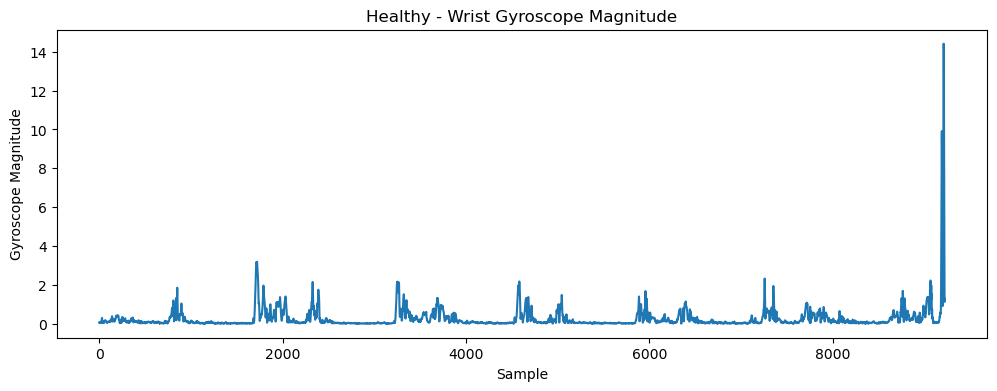

In [77]:
plt.figure(figsize=(12, 4))
plt.plot(healthy_gyr)
plt.title("Healthy - Wrist Gyroscope Magnitude")
plt.xlabel("Sample")
plt.ylabel("Gyroscope Magnitude")
plt.show()

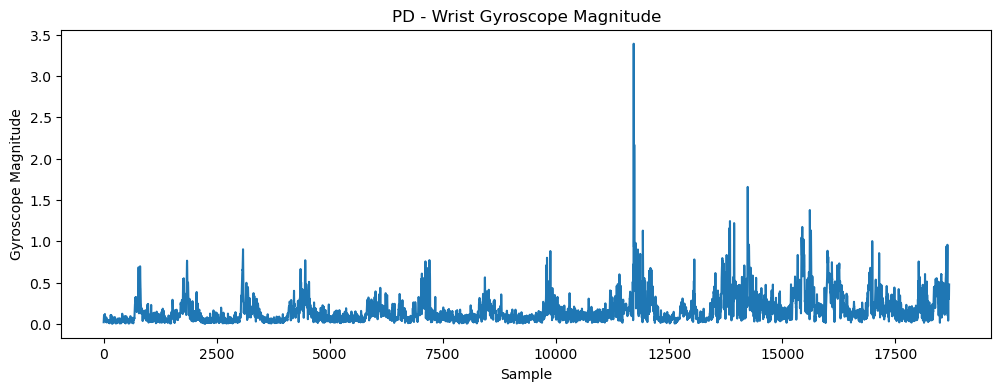

In [78]:
plt.figure(figsize=(12, 4))
plt.plot(pd_gyr)

plt.title("PD - Wrist Gyroscope Magnitude")
plt.xlabel("Sample")
plt.ylabel("Gyroscope Magnitude")

plt.show()

In [79]:
df = pd.read_csv(
    usable_healthy_files[0],
    usecols=["Time"] + balance_features
)

print(df["Time"].head(10))

0       0 sec
1    0.01 sec
2    0.02 sec
3    0.03 sec
4    0.04 sec
5    0.05 sec
6    0.06 sec
7    0.07 sec
8    0.08 sec
9    0.09 sec
Name: Time, dtype: object


In [80]:
print(df["Time"].tail())

9216    92.16 sec
9217    92.17 sec
9218    92.18 sec
9219    92.19 sec
9220     92.2 sec
Name: Time, dtype: object


In [81]:
def create_window(df, window_size = 500):
    windows = []
    for start in range(0, len(df) - window_size + 1, window_size):
        window = df.iloc[start: start + window_size]
        windows.append(window)
    return windows

In [82]:
test_df = pd.read_csv(
    usable_healthy_files[0],
    usecols= balance_features
)

windows = create_window(test_df)

print("Number of windows:", len(windows))
print("First window shape:", windows[0].shape)

Number of windows: 18
First window shape: (500, 6)


In [83]:
def extract_window_feature(window):
    features = {}
    for col in balance_features:
        signal = window[col].dropna()

        features[f"{col}_mean"] = signal.mean()
        features[f"{col}_std"] = signal.std()
        features[f"{col}_min"] = signal.min()
        features[f"{col}_max"] = signal.max()
        features[f"{col}_rms"] = np.sqrt(np.mean(signal ** 2))
    return features

In [84]:
window_features = extract_window_feature(windows[0])

print("Number of features:", len(window_features))

Number of features: 30


In [87]:
pd.Series(window_features)

R_Wrist_Acc_X_mean    8.969491
R_Wrist_Acc_X_std     0.157191
R_Wrist_Acc_X_min     8.431220
R_Wrist_Acc_X_max     9.581541
R_Wrist_Acc_X_rms     8.970865
R_Wrist_Acc_Y_mean   -3.728343
R_Wrist_Acc_Y_std     0.330707
R_Wrist_Acc_Y_min    -4.536511
R_Wrist_Acc_Y_max    -2.731929
R_Wrist_Acc_Y_rms     3.742953
R_Wrist_Acc_Z_mean    1.375282
R_Wrist_Acc_Z_std     0.171173
R_Wrist_Acc_Z_min     0.877462
R_Wrist_Acc_Z_max     1.772297
R_Wrist_Acc_Z_rms     1.385872
R_Wrist_Gyr_X_mean    0.056209
R_Wrist_Gyr_X_std     0.145713
R_Wrist_Gyr_X_min    -0.325521
R_Wrist_Gyr_X_max     0.406885
R_Wrist_Gyr_X_rms     0.156043
R_Wrist_Gyr_Y_mean   -0.025845
R_Wrist_Gyr_Y_std     0.059961
R_Wrist_Gyr_Y_min    -0.156448
R_Wrist_Gyr_Y_max     0.119239
R_Wrist_Gyr_Y_rms     0.065239
R_Wrist_Gyr_Z_mean   -0.007223
R_Wrist_Gyr_Z_std     0.041364
R_Wrist_Gyr_Z_min    -0.143693
R_Wrist_Gyr_Z_max     0.082867
R_Wrist_Gyr_Z_rms     0.041949
dtype: float64

In [88]:
window_data = []
file = usable_healthy_files[0]
df = pd.read_csv(
    file, usecols=balance_features

)

windows = create_window(df, window_size=500)
for window_id, window in enumerate(windows):
    features = extract_window_feature(window)
    features["recording_id"] = file.name
    features["window_id"] = window_id
    features["label"] = 0
    window_data.append(features)

print("Windows created", len(window_data))

Windows created 18


In [90]:
window_df = pd.DataFrame(window_data)
print(window_df.shape)
window_df.head()

(18, 33)


,R_Wrist_Acc_X_mean,R_Wrist_Acc_X_std,R_Wrist_Acc_X_min,R_Wrist_Acc_X_max,R_Wrist_Acc_X_rms,R_Wrist_Acc_Y_mean,R_Wrist_Acc_Y_std,R_Wrist_Acc_Y_min,R_Wrist_Acc_Y_max,R_Wrist_Acc_Y_rms,...,R_Wrist_Gyr_Y_max,R_Wrist_Gyr_Y_rms,R_Wrist_Gyr_Z_mean,R_Wrist_Gyr_Z_std,R_Wrist_Gyr_Z_min,R_Wrist_Gyr_Z_max,R_Wrist_Gyr_Z_rms,recording_id,window_id,label
0,8.969491,0.157191,8.431220,9.581541,8.970865,-3.728343,0.330707,-4.536511,-2.731929,3.742953,...,0.119239,0.065239,-0.007223,0.041364,-0.143693,0.082867,0.041949,HC110_Balance.csv,0,0
1,9.009280,0.453422,7.338787,11.716139,9.020660,-3.649964,0.821912,-7.301501,-0.223597,3.741180,...,0.677379,0.172780,0.009015,0.096533,-0.300818,0.328941,0.096857,HC110_Balance.csv,1,0
2,8.996468,0.056461,8.811527,9.239351,8.996645,-3.718280,0.105520,-3.968353,-3.381356,3.719774,...,0.034764,0.025402,-0.004308,0.019201,-0.087579,0.038923,0.019660,HC110_Balance.csv,2,0
3,8.889552,0.647401,6.817751,10.695491,8.913048,-4.034979,0.931596,-7.687224,-2.433582,4.140917,...,1.449199,0.403860,-0.012189,0.222646,-0.821036,0.503314,0.222757,HC110_Balance.csv,3,0
4,8.943377,0.548516,7.083895,12.769121,8.960149,-3.937865,0.622391,-6.097546,-0.964017,3.986650,...,0.939331,0.220997,0.013619,0.147662,-0.322260,0.810424,0.148141,HC110_Balance.csv,4,0


In [91]:
all_window_data = []

for file in usable_healthy_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_window(
        df,
        window_size=500
    )

    for window_id, window in enumerate(windows):

        features = extract_window_feature(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_window_data.append(features)


for file in usable_pd_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_window(
        df,
        window_size=500
    )

    for window_id, window in enumerate(windows):

        features = extract_window_feature(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_window_data.append(features)


print("Total windows:", len(all_window_data))

Total windows: 5617


In [92]:
window_df = pd.DataFrame(all_window_data)

print("Shape:", window_df.shape)
print("Number of recordings:", window_df["recording_id"].nunique())

Shape: (5617, 33)
Number of recordings: 183


In [93]:
window_df.groupby("recording_id").size().describe()

count    183.000000
mean      30.693989
std        6.753454
min       18.000000
25%       27.000000
50%       29.000000
75%       34.000000
max       63.000000
dtype: float64

In [94]:
from sklearn.model_selection import train_test_split
recording_ids = window_df["recording_id"].unique()

train_ids, test_ids = train_test_split(
    recording_ids,
    test_size=0.2,
    random_state=42,
    stratify= window_df.groupby("recording_id")["label"].first()
)

print("Train recordings:", len(train_ids))
print("Test recordings", len(test_ids))

Train recordings: 146
Test recordings 37


In [95]:
train_df = window_df[
    window_df["recording_id"].isin(train_ids)
].copy()
test_df = window_df[
    window_df["recording_id"].isin(test_ids)
].copy()

print("Train windows:", len(train_df))
print("Test windows:", len(test_df))

Train windows: 4439
Test windows: 1178


In [96]:
feature_cols = balance_features

feature_cols = [
    col + suffix
    for col in balance_features
    for suffix in ["_mean", "_std", "_min", "_max", "_rms"]
]

print("Number of feature columns:", len(feature_cols))

Number of feature columns: 30


In [97]:
X_train = train_df[feature_cols]
y_train = train_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4439, 30)
y_train: (4439,)
X_test: (1178, 30)
y_test: (1178,)


In [98]:
print("Train:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
label
1    2389
0    2050
Name: count, dtype: int64

Test:
label
1    625
0    553
Name: count, dtype: int64


In [99]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state= 42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
y_pred = model.predict(X_test)

In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Healthy", "PD"]
    )
)

Accuracy : 0.5500848896434635
Precision: 0.5801011804384486
Recall   : 0.5504
F1 Score : 0.5648604269293924

Confusion Matrix:
[[304 249]
 [281 344]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.52      0.55      0.53       553
          PD       0.58      0.55      0.56       625

    accuracy                           0.55      1178
   macro avg       0.55      0.55      0.55      1178
weighted avg       0.55      0.55      0.55      1178



In [102]:
test_results = test_df[["recording_id", "label"]].copy()

test_results["prediction"] = y_pred

test_results.head()

,recording_id,label,prediction
18,HC127_Balance.csv,0,1
19,HC127_Balance.csv,0,1
20,HC127_Balance.csv,0,1
21,HC127_Balance.csv,0,1
22,HC127_Balance.csv,0,1


In [103]:
recording_results = (
    test_results
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results["pd_ratio"] = (
    recording_results["pd_windows"] /
    recording_results["total_windows"]
)

recording_results.head()

,recording_id,actual_label,pd_windows,total_windows,pd_ratio
0,HC101_Balance.csv,0,12,25,0.480000
1,HC105_Balance.csv,0,13,33,0.393939
2,HC107_Balance.csv,0,5,30,0.166667
3,HC127_Balance.csv,0,35,44,0.795455
4,HC130_Balance.csv,0,18,44,0.409091


In [104]:
recording_results["final_prediction"] = (
    recording_results["pd_ratio"] >= 0.5
).astype(int)

In [105]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

recording_accuracy = accuracy_score(
    recording_results["actual_label"],
    recording_results["final_prediction"]
)

print("Recording-level accuracy:", recording_accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results["actual_label"],
        recording_results["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_results["actual_label"],
        recording_results["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

Recording-level accuracy: 0.5945945945945946

Confusion Matrix:
[[10  6]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.53      0.62      0.57        16
          PD       0.67      0.57      0.62        21

    accuracy                           0.59        37
   macro avg       0.60      0.60      0.59        37
weighted avg       0.61      0.59      0.60        37



In [106]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importance.head(15))

R_Wrist_Acc_Z_mean    0.057194
R_Wrist_Acc_Y_rms     0.054063
R_Wrist_Acc_Y_mean    0.047243
R_Wrist_Acc_Z_rms     0.039646
R_Wrist_Acc_X_mean    0.038679
R_Wrist_Acc_Y_min     0.037301
R_Wrist_Acc_X_rms     0.036517
R_Wrist_Acc_Z_min     0.036215
R_Wrist_Acc_Z_max     0.035248
R_Wrist_Gyr_X_mean    0.034072
R_Wrist_Gyr_Z_max     0.033467
R_Wrist_Acc_X_max     0.033443
R_Wrist_Acc_Y_max     0.032842
R_Wrist_Gyr_Z_min     0.030798
R_Wrist_Acc_Y_std     0.030573
dtype: float64


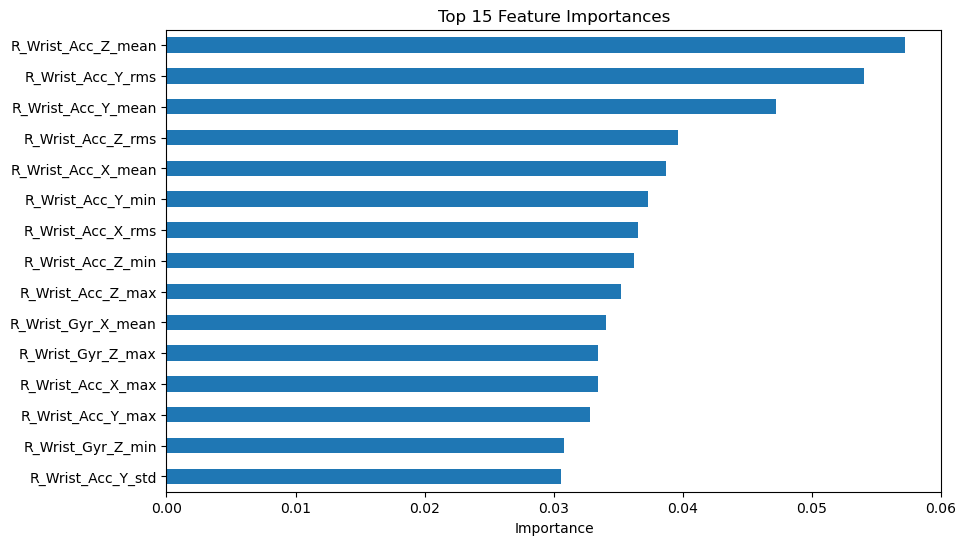

In [107]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [108]:
def extract_window_features_v2(window):
    features = {}

    for col in balance_features:
        signal = window[col].dropna()

        # Existing features
        features[f"{col}_mean"] = signal.mean()
        features[f"{col}_std"] = signal.std()
        features[f"{col}_min"] = signal.min()
        features[f"{col}_max"] = signal.max()
        features[f"{col}_rms"] = np.sqrt(np.mean(signal ** 2))

        # Movement / dynamic features
        diff = signal.diff().dropna()

        features[f"{col}_diff_mean"] = diff.abs().mean()
        features[f"{col}_diff_std"] = diff.std()
        features[f"{col}_energy"] = np.mean(signal ** 2)

    return features

In [109]:
test_features = extract_window_features_v2(windows[0])

print("Number of features:", len(test_features))

Number of features: 48


In [110]:
pd.Series(test_features)

R_Wrist_Acc_X_mean          8.972216
R_Wrist_Acc_X_std           0.092077
R_Wrist_Acc_X_min           8.687011
R_Wrist_Acc_X_max           9.168358
R_Wrist_Acc_X_rms           8.972687
R_Wrist_Acc_X_diff_mean     0.026897
R_Wrist_Acc_X_diff_std      0.034496
R_Wrist_Acc_X_energy       80.509114
R_Wrist_Acc_Y_mean         -3.906703
R_Wrist_Acc_Y_std           0.174503
R_Wrist_Acc_Y_min          -4.366652
R_Wrist_Acc_Y_max          -3.462002
R_Wrist_Acc_Y_rms           3.910591
R_Wrist_Acc_Y_diff_mean     0.035035
R_Wrist_Acc_Y_diff_std      0.045172
R_Wrist_Acc_Y_energy       15.292721
R_Wrist_Acc_Z_mean          0.548067
R_Wrist_Acc_Z_std           0.194439
R_Wrist_Acc_Z_min           0.109437
R_Wrist_Acc_Z_max           0.971779
R_Wrist_Acc_Z_rms           0.581471
R_Wrist_Acc_Z_diff_mean     0.026967
R_Wrist_Acc_Z_diff_std      0.034442
R_Wrist_Acc_Z_energy        0.338109
R_Wrist_Gyr_X_mean         -0.019476
R_Wrist_Gyr_X_std           0.046987
R_Wrist_Gyr_X_min          -0.151931
R

In [113]:
all_window_data_v2 = []

# Healthy
for file in usable_healthy_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_window(
        df,
        window_size=500
    )

    for window_id, window in enumerate(windows):

        features = extract_window_features_v2(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_window_data_v2.append(features)


# PD
for file in usable_pd_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_window(
        df,
        window_size=500
    )

    for window_id, window in enumerate(windows):

        features = extract_window_features_v2(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_window_data_v2.append(features)


window_df_v2 = pd.DataFrame(all_window_data_v2)

print("Shape:", window_df_v2.shape)
print("Recordings:", window_df_v2["recording_id"].nunique())

Shape: (5617, 51)
Recordings: 183


In [114]:
train_df_v2 = window_df_v2[
    window_df_v2["recording_id"].isin(train_ids)
].copy()

test_df_v2 = window_df_v2[
    window_df_v2["recording_id"].isin(test_ids)
].copy()

print("Train windows:", len(train_df_v2))
print("Test windows:", len(test_df_v2))

Train windows: 4439
Test windows: 1178


In [115]:
feature_cols_v2 = [
    col for col in window_df_v2.columns
    if col not in ["recording_id", "window_id", "label"]
]

print("Features:", len(feature_cols_v2))

Features: 48


In [116]:
X_train_v2 = train_df_v2[feature_cols_v2]
y_train_v2 = train_df_v2["label"]

X_test_v2 = test_df_v2[feature_cols_v2]
y_test_v2 = test_df_v2["label"]

print(X_train_v2.shape)
print(X_test_v2.shape)

(4439, 48)
(1178, 48)


In [117]:
model_v2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

In [118]:
print("Accuracy :", accuracy_score(y_test_v2, y_pred_v2))
print("Precision:", precision_score(y_test_v2, y_pred_v2))
print("Recall   :", recall_score(y_test_v2, y_pred_v2))
print("F1 Score :", f1_score(y_test_v2, y_pred_v2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_v2))

Accuracy : 0.5636672325976231
Precision: 0.5885167464114832
Recall   : 0.5904
F1 Score : 0.5894568690095847

Confusion Matrix:
[[295 258]
 [256 369]]


In [119]:
test_results_v2 = test_df_v2[
    ["recording_id", "label"]
].copy()

test_results_v2["prediction"] = y_pred_v2

recording_results_v2 = (
    test_results_v2
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results_v2["pd_ratio"] = (
    recording_results_v2["pd_windows"] /
    recording_results_v2["total_windows"]
)

recording_results_v2["final_prediction"] = (
    recording_results_v2["pd_ratio"] >= 0.5
).astype(int)

In [120]:
recording_accuracy_v2 = accuracy_score(
    recording_results_v2["actual_label"],
    recording_results_v2["final_prediction"]
)

print("V2 Recording-level accuracy:", recording_accuracy_v2)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results_v2["actual_label"],
        recording_results_v2["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_results_v2["actual_label"],
        recording_results_v2["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

V2 Recording-level accuracy: 0.5675675675675675

Confusion Matrix:
[[ 8  8]
 [ 8 13]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.50      0.50      0.50        16
          PD       0.62      0.62      0.62        21

    accuracy                           0.57        37
   macro avg       0.56      0.56      0.56        37
weighted avg       0.57      0.57      0.57        37



In [121]:
time_values = (
    df["Time"]
    .str.replace(" sec", "", regex=False)
    .astype(float)
)

dt = time_values.diff().median()

print("Sampling interval:", dt)
print("Sampling rate:", 1 / dt)

KeyError: 'Time'

In [122]:
sample_df = pd.read_csv(usable_healthy_files[0])

print(sample_df["Time"].head())

0       0 sec
1    0.01 sec
2    0.02 sec
3    0.03 sec
4    0.04 sec
Name: Time, dtype: object


In [124]:
time_values = (
    sample_df["Time"]
    .str.replace(" sec", "", regex=False)
    .astype(float)
)

dt = time_values.diff().median()

print("Sampling interval:", dt)
print("Sampling rate:", 1 / dt)

Sampling interval: 0.009999999999999787
Sampling rate: 100.00000000000213


In [125]:
from scipy.fft import rfft, rfftfreq

sample_signal = windows[0]["R_Wrist_Acc_X"].values

n = len(sample_signal)

fft_values = np.abs(rfft(sample_signal))
frequencies = rfftfreq(n, d=1/100)

print("Samples:", n)
print("Frequency bins:", len(frequencies))
print("Frequency range:", frequencies[0], "to", frequencies[-1], "Hz")

Samples: 500
Frequency bins: 251
Frequency range: 0.0 to 50.0 Hz


In [126]:
power = fft_values ** 2

dominant_idx = np.argmax(power[1:]) + 1

print("Dominant frequency:",
      frequencies[dominant_idx], "Hz")

print("Dominant power:",
      power[dominant_idx])

Dominant frequency: 0.2 Hz
Dominant power: 472.4065207345591


In [127]:
# Ignore frequencies below 1 Hz
valid = frequencies >= 1.0

freq_valid = frequencies[valid]
power_valid = power[valid]

dominant_idx = np.argmax(power_valid)

print("Dominant frequency above 1 Hz:",
      freq_valid[dominant_idx], "Hz")

print("Dominant power:",
      power_valid[dominant_idx])

Dominant frequency above 1 Hz: 1.8 Hz
Dominant power: 46.49766360646429


In [128]:
top_indices = np.argsort(power_valid)[-10:][::-1]

for i in top_indices:
    print(
        f"{freq_valid[i]:.2f} Hz -> "
        f"{power_valid[i]:.2f}"
    )

1.80 Hz -> 46.50
3.00 Hz -> 29.36
2.20 Hz -> 26.50
1.40 Hz -> 24.20
5.60 Hz -> 22.50
5.00 Hz -> 21.31
6.00 Hz -> 20.02
1.00 Hz -> 17.86
4.40 Hz -> 17.64
7.40 Hz -> 15.66


In [129]:
from scipy.fft import rfft, rfftfreq

def extract_frequency_features(window, sampling_rate=100):
    features = {}

    for col in balance_features:

        signal = window[col].values

        n = len(signal)

        # Remove mean/DC component
        signal = signal - np.mean(signal)

        # FFT
        fft_values = np.abs(rfft(signal))
        power = fft_values ** 2

        frequencies = rfftfreq(
            n,
            d=1 / sampling_rate
        )

        # Ignore frequencies below 1 Hz
        valid = frequencies >= 1.0

        freq_valid = frequencies[valid]
        power_valid = power[valid]

        # Dominant frequency
        dominant_idx = np.argmax(power_valid)

        dominant_frequency = freq_valid[dominant_idx]
        dominant_power = power_valid[dominant_idx]

        # Spectral entropy
        power_sum = np.sum(power_valid)

        if power_sum > 0:
            probability = power_valid / power_sum
            spectral_entropy = -np.sum(
                probability * np.log2(probability + 1e-12)
            )
        else:
            spectral_entropy = 0

        features[f"{col}_dominant_freq"] = dominant_frequency
        features[f"{col}_dominant_power"] = dominant_power
        features[f"{col}_spectral_entropy"] = spectral_entropy

    return features

In [131]:
freq_features = extract_frequency_features(windows[0])

print("Number of frequency features:", len(freq_features))

pd.Series(freq_features)

Number of frequency features: 18


R_Wrist_Acc_X_dominant_freq         1.800000
R_Wrist_Acc_X_dominant_power       46.497664
R_Wrist_Acc_X_spectral_entropy      5.776785
R_Wrist_Acc_Y_dominant_freq         4.600000
R_Wrist_Acc_Y_dominant_power      273.418320
R_Wrist_Acc_Y_spectral_entropy      4.881636
R_Wrist_Acc_Z_dominant_freq         4.600000
R_Wrist_Acc_Z_dominant_power      159.397039
R_Wrist_Acc_Z_spectral_entropy      5.108804
R_Wrist_Gyr_X_dominant_freq         1.400000
R_Wrist_Gyr_X_dominant_power       19.076868
R_Wrist_Gyr_X_spectral_entropy      4.545301
R_Wrist_Gyr_Y_dominant_freq         1.800000
R_Wrist_Gyr_Y_dominant_power        4.075714
R_Wrist_Gyr_Y_spectral_entropy      4.736183
R_Wrist_Gyr_Z_dominant_freq         1.000000
R_Wrist_Gyr_Z_dominant_power        5.569669
R_Wrist_Gyr_Z_spectral_entropy      4.634083
dtype: float64

In [133]:
def extract_window_features_v3(window):
    features = {}

    # Original 30 statistical features
    basic_features = extract_window_feature(window)
    features.update(basic_features)

    # 18 frequency features
    frequency_features = extract_frequency_features(window)
    features.update(frequency_features)

    return features

In [134]:
test_v3 = extract_window_features_v3(windows[0])

print("Total features:", len(test_v3))

Total features: 48


In [137]:
all_window_data_v3 = []

# Healthy
for file in usable_healthy_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_window(df, 500)

    for window_id, window in enumerate(windows):

        features = extract_window_features_v3(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_window_data_v3.append(features)


# PD
for file in usable_pd_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_window(df, 500)

    for window_id, window in enumerate(windows):

        features = extract_window_features_v3(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_window_data_v3.append(features)


window_df_v3 = pd.DataFrame(all_window_data_v3)

print("Shape:", window_df_v3.shape)
print("Recordings:", window_df_v3["recording_id"].nunique())

Shape: (5617, 51)
Recordings: 183


In [138]:
train_df_v3 = window_df_v3[
    window_df_v3["recording_id"].isin(train_ids)
].copy()

test_df_v3 = window_df_v3[
    window_df_v3["recording_id"].isin(test_ids)
].copy()

feature_cols_v3 = [
    col for col in window_df_v3.columns
    if col not in ["recording_id", "window_id", "label"]
]

X_train_v3 = train_df_v3[feature_cols_v3]
y_train_v3 = train_df_v3["label"]

X_test_v3 = test_df_v3[feature_cols_v3]
y_test_v3 = test_df_v3["label"]

print("Features:", len(feature_cols_v3))
print("Train:", X_train_v3.shape)
print("Test:", X_test_v3.shape)

Features: 48
Train: (4439, 48)
Test: (1178, 48)


In [139]:
model_v3 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = model_v3.predict(X_test_v3)

In [140]:
print("Accuracy :", accuracy_score(y_test_v3, y_pred_v3))

Accuracy : 0.5721561969439728


In [143]:
test_results_v3 = test_df_v3[
    ["recording_id", "label"]
].copy()

test_results_v3["prediction"] = y_pred_v3

recording_results_v3 = (
    test_results_v3
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results_v3["pd_ratio"] = (
    recording_results_v3["pd_windows"] /
    recording_results_v3["total_windows"]
)

print(recording_results_v3.head())

        recording_id  actual_label  pd_windows  total_windows  pd_ratio
0  HC101_Balance.csv             0           4             25  0.160000
1  HC105_Balance.csv             0          13             33  0.393939
2  HC107_Balance.csv             0           5             30  0.166667
3  HC127_Balance.csv             0          37             44  0.840909
4  HC130_Balance.csv             0          16             44  0.363636


In [144]:
recording_results_v3["final_prediction"] = (
    recording_results_v3["pd_ratio"] >= 0.5
).astype(int)

In [145]:
recording_accuracy_v3 = accuracy_score(
    recording_results_v3["actual_label"],
    recording_results_v3["final_prediction"]
)

print("V3 Recording-level accuracy:", recording_accuracy_v3)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results_v3["actual_label"],
        recording_results_v3["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_results_v3["actual_label"],
        recording_results_v3["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

V3 Recording-level accuracy: 0.6216216216216216

Confusion Matrix:
[[10  6]
 [ 8 13]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.56      0.62      0.59        16
          PD       0.68      0.62      0.65        21

    accuracy                           0.62        37
   macro avg       0.62      0.62      0.62        37
weighted avg       0.63      0.62      0.62        37



In [146]:
importance_v3 = pd.Series(
    model_v3.feature_importances_,
    index=feature_cols_v3
).sort_values(ascending=False)

print(importance_v3.head(20))

R_Wrist_Acc_Z_mean                0.042911
R_Wrist_Acc_Y_mean                0.039482
R_Wrist_Acc_Y_rms                 0.039366
R_Wrist_Acc_Z_rms                 0.028897
R_Wrist_Acc_X_mean                0.027086
R_Wrist_Acc_Z_min                 0.026715
R_Wrist_Acc_Y_spectral_entropy    0.026570
R_Wrist_Acc_X_rms                 0.025386
R_Wrist_Acc_Y_min                 0.024690
R_Wrist_Acc_Z_max                 0.024121
R_Wrist_Acc_Z_spectral_entropy    0.023249
R_Wrist_Acc_Y_max                 0.022363
R_Wrist_Gyr_X_mean                0.022235
R_Wrist_Gyr_Z_spectral_entropy    0.022070
R_Wrist_Gyr_X_spectral_entropy    0.021657
R_Wrist_Acc_X_max                 0.021148
R_Wrist_Gyr_X_dominant_power      0.020230
R_Wrist_Acc_X_min                 0.019635
R_Wrist_Gyr_Z_max                 0.019549
R_Wrist_Gyr_Y_spectral_entropy    0.019491
dtype: float64


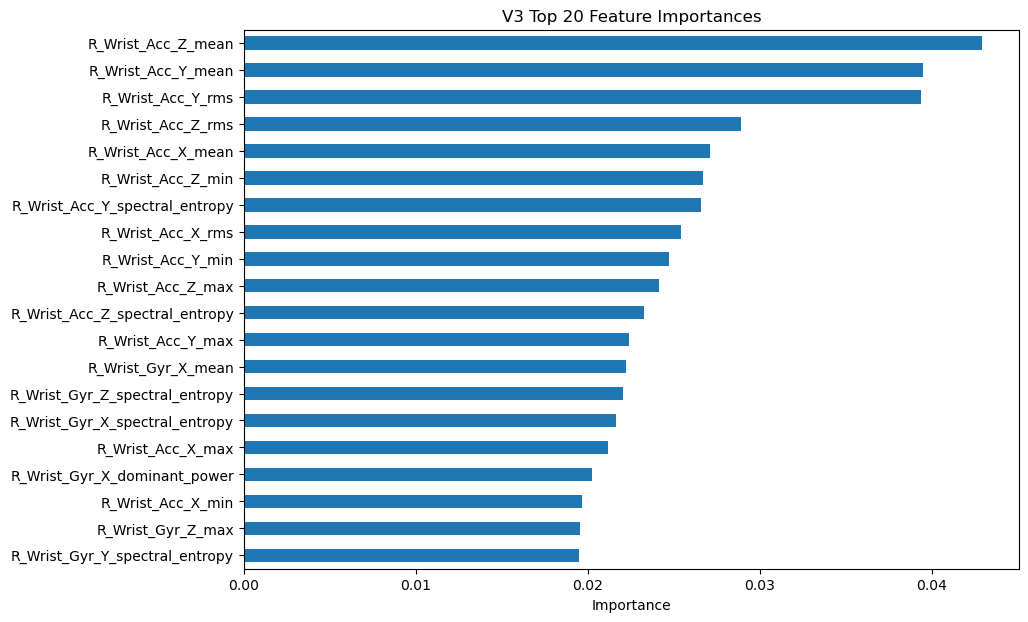

In [147]:
plt.figure(figsize=(10, 7))

importance_v3.head(20).sort_values().plot(
    kind="barh"
)

plt.title("V3 Top 20 Feature Importances")
plt.xlabel("Importance")

plt.show()

In [148]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score
import numpy as np

X_cv = train_df_v3[feature_cols_v3]
y_cv = train_df_v3["label"]
groups = train_df_v3["recording_id"]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_cv, y_cv, groups=groups),
    start=1
):

    X_fold_train = X_cv.iloc[train_idx]
    y_fold_train = y_cv.iloc[train_idx]

    X_fold_val = X_cv.iloc[val_idx]
    y_fold_val = y_cv.iloc[val_idx]

    fold_train_df = train_df_v3.iloc[train_idx].copy()
    fold_val_df = train_df_v3.iloc[val_idx].copy()

    model_fold = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_fold.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_fold.predict(X_fold_val)

    # Put predictions back with recording IDs
    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    # Aggregate windows → recording
    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores.append(fold_accuracy)

    print(
        f"Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

Fold 1: 0.6207 (62.07%)
Fold 2: 0.5517 (55.17%)
Fold 3: 0.6552 (65.52%)
Fold 4: 0.7586 (75.86%)
Fold 5: 0.6667 (66.67%)


In [149]:
print("\nCV Mean Accuracy:",
      np.mean(fold_scores))

print("CV Std:",
      np.std(fold_scores))


CV Mean Accuracy: 0.6505747126436782
CV Std: 0.06725856937162203


In [150]:
basic_feature_cols = [
    col for col in feature_cols_v3
    if not (
        col.endswith("_dominant_freq") or
        col.endswith("_dominant_power") or
        col.endswith("_spectral_entropy")
    )
]

print("V1 features:", len(basic_feature_cols))

V1 features: 30


In [151]:
X_cv_v1 = train_df_v3[basic_feature_cols]
y_cv_v1 = train_df_v3["label"]
groups_v1 = train_df_v3["recording_id"]

In [152]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

cv_v1 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_v1 = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v1.split(X_cv_v1, y_cv_v1, groups=groups_v1),
    start=1
):

    X_fold_train = X_cv_v1.iloc[train_idx]
    y_fold_train = y_cv_v1.iloc[train_idx]

    X_fold_val = X_cv_v1.iloc[val_idx]
    y_fold_val = y_cv_v1.iloc[val_idx]

    fold_train_df = train_df_v3.iloc[train_idx].copy()
    fold_val_df = train_df_v3.iloc[val_idx].copy()

    model_v1_cv = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_v1_cv.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_v1_cv.predict(X_fold_val)

    # Window predictions
    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    # Window → recording
    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_v1.append(fold_accuracy)

    print(
        f"V1 Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

V1 Fold 1: 0.6897 (68.97%)
V1 Fold 2: 0.5862 (58.62%)
V1 Fold 3: 0.6552 (65.52%)
V1 Fold 4: 0.6897 (68.97%)
V1 Fold 5: 0.6000 (60.00%)


In [153]:
print(
    "\nV1 CV Mean Accuracy:",
    np.mean(fold_scores_v1)
)

print(
    "V1 CV Std:",
    np.std(fold_scores_v1)
)


V1 CV Mean Accuracy: 0.6441379310344828
V1 CV Std: 0.04374828007490681


In [154]:
from sklearn.linear_model import LogisticRegression

In [155]:
cv_lr = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_lr = []

for fold, (train_idx, val_idx) in enumerate(
    cv_lr.split(X_cv_v1, y_cv_v1, groups=groups_v1),
    start=1
):

    X_fold_train = X_cv_v1.iloc[train_idx]
    y_fold_train = y_cv_v1.iloc[train_idx]

    X_fold_val = X_cv_v1.iloc[val_idx]
    y_fold_val = y_cv_v1.iloc[val_idx]

    fold_val_df = train_df_v3.iloc[val_idx].copy()

    model_lr = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    model_lr.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_lr.predict(X_fold_val)

    # Window predictions → recording predictions
    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_lr.append(fold_accuracy)

    print(
        f"LR Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [156]:
print("NaN values:", X_cv_v1.isna().sum().sum())
print("\nFeatures with NaN:")
print(X_cv_v1.columns[X_cv_v1.isna().any()].tolist())

NaN values: 930

Features with NaN:
['R_Wrist_Acc_X_mean', 'R_Wrist_Acc_X_std', 'R_Wrist_Acc_X_min', 'R_Wrist_Acc_X_max', 'R_Wrist_Acc_X_rms', 'R_Wrist_Acc_Y_mean', 'R_Wrist_Acc_Y_std', 'R_Wrist_Acc_Y_min', 'R_Wrist_Acc_Y_max', 'R_Wrist_Acc_Y_rms', 'R_Wrist_Acc_Z_mean', 'R_Wrist_Acc_Z_std', 'R_Wrist_Acc_Z_min', 'R_Wrist_Acc_Z_max', 'R_Wrist_Acc_Z_rms', 'R_Wrist_Gyr_X_mean', 'R_Wrist_Gyr_X_std', 'R_Wrist_Gyr_X_min', 'R_Wrist_Gyr_X_max', 'R_Wrist_Gyr_X_rms', 'R_Wrist_Gyr_Y_mean', 'R_Wrist_Gyr_Y_std', 'R_Wrist_Gyr_Y_min', 'R_Wrist_Gyr_Y_max', 'R_Wrist_Gyr_Y_rms', 'R_Wrist_Gyr_Z_mean', 'R_Wrist_Gyr_Z_std', 'R_Wrist_Gyr_Z_min', 'R_Wrist_Gyr_Z_max', 'R_Wrist_Gyr_Z_rms']


In [157]:
print("Inf values:", np.isinf(X_cv_v1).sum().sum())

Inf values: 0


In [158]:
nan_rows = train_df_v3[
    train_df_v3[feature_cols_v3].isna().any(axis=1)
]

print("Bad windows:", len(nan_rows))

print(
    nan_rows[
        ["recording_id", "window_id", "label"]
    ].head(20)
)

Bad windows: 61
           recording_id  window_id  label
1284  HC111_Balance.csv         12      0
1285  HC111_Balance.csv         13      0
1286  HC111_Balance.csv         14      0
1287  HC111_Balance.csv         15      0
1288  HC111_Balance.csv         16      0
1289  HC111_Balance.csv         17      0
1290  HC111_Balance.csv         18      0
1291  HC111_Balance.csv         19      0
1292  HC111_Balance.csv         20      0
1293  HC111_Balance.csv         21      0
1294  HC111_Balance.csv         22      0
1296  HC111_Balance.csv         24      0
1297  HC111_Balance.csv         25      0
1469  HC128_Balance.csv          4      0
1470  HC128_Balance.csv          5      0
1471  HC128_Balance.csv          6      0
1472  HC128_Balance.csv          7      0
1473  HC128_Balance.csv          8      0
1474  HC128_Balance.csv          9      0
1475  HC128_Balance.csv         10      0


In [159]:
print(
    nan_rows["recording_id"].value_counts()
)

recording_id
WPD018_Balance.csv    17
WPD022_Balance.csv    16
HC111_Balance.csv     13
HC128_Balance.csv     12
HC136_Balance.csv      3
Name: count, dtype: int64


In [160]:
bad_file = next(
    f for f in usable_healthy_files + usable_pd_files
    if f.name == "HC111_Balance.csv"
)

bad_df = pd.read_csv(
    bad_file,
    usecols=balance_features
)

print("Shape:", bad_df.shape)
print("\nNaN count:")
print(bad_df.isna().sum())

print("\nInf count:")
print(np.isinf(bad_df).sum())

Shape: (13840, 6)

NaN count:
R_Wrist_Acc_X    1889
R_Wrist_Acc_Y    1889
R_Wrist_Acc_Z    1889
R_Wrist_Gyr_X    1889
R_Wrist_Gyr_Y    1889
R_Wrist_Gyr_Z    1889
dtype: int64

Inf count:
R_Wrist_Acc_X    0
R_Wrist_Acc_Y    0
R_Wrist_Acc_Z    0
R_Wrist_Gyr_X    0
R_Wrist_Gyr_Y    0
R_Wrist_Gyr_Z    0
dtype: int64


In [161]:
print(
    bad_df.iloc[12*500:13*500].isna().sum()
)

R_Wrist_Acc_X    57
R_Wrist_Acc_Y    57
R_Wrist_Acc_Z    57
R_Wrist_Gyr_X    57
R_Wrist_Gyr_Y    57
R_Wrist_Gyr_Z    57
dtype: int64


In [162]:
for window_id in [11, 12, 13, 22, 23, 24, 25]:
    
    start = window_id * 500
    end = start + 500
    
    window = bad_df.iloc[start:end]

    print(
        f"Window {window_id}:",
        "rows =", len(window),
        "valid =", window.notna().sum().min(),
        "NaN =", window.isna().sum().max()
    )

Window 11: rows = 500 valid = 500 NaN = 0
Window 12: rows = 500 valid = 443 NaN = 57
Window 13: rows = 500 valid = 273 NaN = 227
Window 22: rows = 500 valid = 412 NaN = 88
Window 23: rows = 500 valid = 500 NaN = 0
Window 24: rows = 500 valid = 493 NaN = 7
Window 25: rows = 500 valid = 459 NaN = 41


In [163]:
def create_windows(df, window_size=500, min_valid_ratio=0.90):

    windows = []

    for start in range(0, len(df) - window_size + 1, window_size):

        window = df.iloc[start:start + window_size].copy()

        valid_ratio = (
            window[balance_features]
            .notna()
            .all(axis=1)
            .mean()
        )

        if valid_ratio >= min_valid_ratio:
            windows.append(window)

    return windows

In [164]:
hc111_windows = create_windows(
    bad_df,
    window_size=500,
    min_valid_ratio=0.90
)

print("Usable windows:", len(hc111_windows))

Usable windows: 17


SyntaxError: invalid syntax (526379376.py, line 1)

In [166]:
all_window_data_clean = []

for file in usable_healthy_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_windows(
        df,
        window_size=500,
        min_valid_ratio=0.90
    )

    for window_id, window in enumerate(windows):

        features = extract_window_features_v3(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        all_window_data_clean.append(features)


for file in usable_pd_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_windows(
        df,
        window_size=500,
        min_valid_ratio=0.90
    )

    for window_id, window in enumerate(windows):

        features = extract_window_features_v3(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        all_window_data_clean.append(features)


clean_window_df = pd.DataFrame(all_window_data_clean)

print("Shape:", clean_window_df.shape)
print("Recordings:", clean_window_df["recording_id"].nunique())
print("NaN:", clean_window_df.isna().sum().sum())
print("Inf:", np.isinf(
    clean_window_df.select_dtypes(include=np.number)
).sum().sum())

Shape: (5525, 51)
Recordings: 183
NaN: 36
Inf: 0


In [167]:
print("Clean windows:", len(clean_window_df))

Clean windows: 5525


In [168]:
nan_counts = clean_window_df.isna().sum()

print(
    nan_counts[nan_counts > 0]
)

R_Wrist_Acc_X_dominant_power    6
R_Wrist_Acc_Y_dominant_power    6
R_Wrist_Acc_Z_dominant_power    6
R_Wrist_Gyr_X_dominant_power    6
R_Wrist_Gyr_Y_dominant_power    6
R_Wrist_Gyr_Z_dominant_power    6
dtype: int64


In [169]:
bad_clean_windows = clean_window_df[
    clean_window_df.isna().any(axis=1)
]

print("Bad windows:", len(bad_clean_windows))

print(
    bad_clean_windows[
        ["recording_id", "window_id", "label"]
    ]
)

Bad windows: 6
           recording_id  window_id  label
1284  HC111_Balance.csv         12      0
1286  HC111_Balance.csv         14      0
1287  HC111_Balance.csv         15      0
1677  HC136_Balance.csv         42      0
1678  HC136_Balance.csv         43      0
1679  HC136_Balance.csv         44      0


In [171]:
bad_features = clean_window_df.loc[
    bad_clean_windows.index
].isna().sum()

print(bad_features[bad_features > 0])

R_Wrist_Acc_X_dominant_power    6
R_Wrist_Acc_Y_dominant_power    6
R_Wrist_Acc_Z_dominant_power    6
R_Wrist_Gyr_X_dominant_power    6
R_Wrist_Gyr_Y_dominant_power    6
R_Wrist_Gyr_Z_dominant_power    6
dtype: int64


In [172]:
print(
    clean_window_df.loc[
        bad_clean_windows.index,
        ["recording_id", "window_id"] +
        [col for col in feature_cols_v3
         if clean_window_df.loc[bad_clean_windows.index, col].isna().any()]
    ]
)

           recording_id  window_id  R_Wrist_Acc_X_dominant_power  \
1284  HC111_Balance.csv         12                           NaN   
1286  HC111_Balance.csv         14                           NaN   
1287  HC111_Balance.csv         15                           NaN   
1677  HC136_Balance.csv         42                           NaN   
1678  HC136_Balance.csv         43                           NaN   
1679  HC136_Balance.csv         44                           NaN   

      R_Wrist_Acc_Y_dominant_power  R_Wrist_Acc_Z_dominant_power  \
1284                           NaN                           NaN   
1286                           NaN                           NaN   
1287                           NaN                           NaN   
1677                           NaN                           NaN   
1678                           NaN                           NaN   
1679                           NaN                           NaN   

      R_Wrist_Gyr_X_dominant_power  R_Wrist_Gy

In [173]:
clean_window_df = clean_window_df.drop(
    index=bad_clean_windows.index
).reset_index(drop=True)

print("Final windows:", len(clean_window_df))
print("NaN:", clean_window_df.isna().sum().sum())
print(
    "Inf:",
    np.isinf(
        clean_window_df.select_dtypes(include=np.number)
    ).sum().sum()
)

Final windows: 5519
NaN: 0
Inf: 0


In [174]:
train_clean = clean_window_df[
    clean_window_df["recording_id"].isin(train_ids)
].copy()

test_clean = clean_window_df[
    clean_window_df["recording_id"].isin(test_ids)
].copy()

print("Train windows:", len(train_clean))
print("Test windows:", len(test_clean))

print("Train recordings:", train_clean["recording_id"].nunique())
print("Test recordings:", test_clean["recording_id"].nunique())

Train windows: 4378
Test windows: 1141
Train recordings: 146
Test recordings: 37


In [175]:
X_train_clean_v1 = train_clean[basic_feature_cols]
y_train_clean = train_clean["label"]

X_test_clean_v1 = test_clean[basic_feature_cols]
y_test_clean = test_clean["label"]

print("V1 features:", len(basic_feature_cols))
print("Train:", X_train_clean_v1.shape)
print("Test:", X_test_clean_v1.shape)

V1 features: 30
Train: (4378, 30)
Test: (1141, 30)


In [176]:
print("Train NaN:", X_train_clean_v1.isna().sum().sum())
print("Test NaN :", X_test_clean_v1.isna().sum().sum())

print("Train Inf:", np.isinf(X_train_clean_v1).sum().sum())
print("Test Inf :", np.isinf(X_test_clean_v1).sum().sum())

Train NaN: 0
Test NaN : 0
Train Inf: 0
Test Inf : 0


SyntaxError: invalid syntax (1630175473.py, line 1)

In [179]:
X_cv_v1_clean = train_clean[basic_feature_cols]
y_cv_v1_clean = train_clean["label"]
groups_v1_clean = train_clean["recording_id"]

In [180]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

cv_lr = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_lr = []

for fold, (train_idx, val_idx) in enumerate(
    cv_lr.split(
        X_cv_v1_clean,
        y_cv_v1_clean,
        groups=groups_v1_clean
    ),
    start=1
):

    X_fold_train = X_cv_v1_clean.iloc[train_idx]
    y_fold_train = y_cv_v1_clean.iloc[train_idx]

    X_fold_val = X_cv_v1_clean.iloc[val_idx]

    fold_val_df = train_clean.iloc[val_idx].copy()

    model_lr = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    model_lr.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_lr.predict(X_fold_val)

    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_lr.append(fold_accuracy)

    print(
        f"LR Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

LR Fold 1: 0.6897 (68.97%)
LR Fold 2: 0.6333 (63.33%)
LR Fold 3: 0.6207 (62.07%)
LR Fold 4: 0.6207 (62.07%)
LR Fold 5: 0.5517 (55.17%)


In [181]:
print(
    "\nLogistic Regression CV Mean:",
    np.mean(fold_scores_lr)
)

print(
    "Logistic Regression CV Std:",
    np.std(fold_scores_lr)
)


Logistic Regression CV Mean: 0.6232183908045977
Logistic Regression CV Std: 0.04390985131992936


In [182]:
X_train_v4 = train_clean[feature_cols_v3]
y_train_v4 = train_clean["label"]

X_test_v4 = test_clean[feature_cols_v3]
y_test_v4 = test_clean["label"]

print("Train:", X_train_v4.shape)
print("Test :", X_test_v4.shape)
print("NaN:", X_train_v4.isna().sum().sum())
print("Inf:", np.isinf(X_train_v4).sum().sum())

Train: (4378, 48)
Test : (1141, 48)
NaN: 0
Inf: 0


In [183]:
model_v4 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_v4.fit(
    X_train_v4,
    y_train_v4
)

y_pred_v4 = model_v4.predict(X_test_v4)

In [184]:
print("Accuracy :", accuracy_score(y_test_v4, y_pred_v4))
print("Precision:", precision_score(y_test_v4, y_pred_v4))
print("Recall   :", recall_score(y_test_v4, y_pred_v4))
print("F1 Score :", f1_score(y_test_v4, y_pred_v4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v4, y_pred_v4))

Accuracy : 0.5591586327782647
Precision: 0.5892547660311959
Recall   : 0.5610561056105611
F1 Score : 0.5748098055790364

Confusion Matrix:
[[298 237]
 [266 340]]


In [185]:
test_results_v4 = test_clean[
    ["recording_id", "label"]
].copy()

test_results_v4["prediction"] = y_pred_v4

recording_results_v4 = (
    test_results_v4
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results_v4["pd_ratio"] = (
    recording_results_v4["pd_windows"] /
    recording_results_v4["total_windows"]
)

recording_results_v4["final_prediction"] = (
    recording_results_v4["pd_ratio"] >= 0.5
).astype(int)

In [186]:
recording_accuracy_v4 = accuracy_score(
    recording_results_v4["actual_label"],
    recording_results_v4["final_prediction"]
)

print(
    "V4 Recording-level accuracy:",
    recording_accuracy_v4
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results_v4["actual_label"],
        recording_results_v4["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_results_v4["actual_label"],
        recording_results_v4["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

V4 Recording-level accuracy: 0.5945945945945946

Confusion Matrix:
[[10  6]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.53      0.62      0.57        16
          PD       0.67      0.57      0.62        21

    accuracy                           0.59        37
   macro avg       0.60      0.60      0.59        37
weighted avg       0.61      0.59      0.60        37



In [187]:
X_cv_clean = train_clean[basic_feature_cols]
y_cv_clean = train_clean["label"]
groups_clean = train_clean["recording_id"]

In [188]:
X_cv_clean = train_clean[basic_feature_cols]
y_cv_clean = train_clean["label"]
groups_clean = train_clean["recording_id"]

print("Features:", X_cv_clean.shape[1])
print("NaN:", X_cv_clean.isna().sum().sum())
print("Inf:", np.isinf(X_cv_clean).sum().sum())

Features: 30
NaN: 0
Inf: 0


In [189]:
cv_clean_rf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_clean_rf = []

for fold, (train_idx, val_idx) in enumerate(
    cv_clean_rf.split(
        X_cv_clean,
        y_cv_clean,
        groups=groups_clean
    ),
    start=1
):

    X_fold_train = X_cv_clean.iloc[train_idx]
    y_fold_train = y_cv_clean.iloc[train_idx]

    X_fold_val = X_cv_clean.iloc[val_idx]

    fold_val_df = train_clean.iloc[val_idx].copy()

    model_clean_rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_clean_rf.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_clean_rf.predict(X_fold_val)

    # Window → recording
    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_clean_rf.append(fold_accuracy)

    print(
        f"Clean V1 Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

Clean V1 Fold 1: 0.6552 (65.52%)
Clean V1 Fold 2: 0.6000 (60.00%)
Clean V1 Fold 3: 0.6897 (68.97%)
Clean V1 Fold 4: 0.6552 (65.52%)
Clean V1 Fold 5: 0.5862 (58.62%)


In [190]:
print(
    "\nClean V1 RF Mean:",
    np.mean(fold_scores_clean_rf)
)

print(
    "Clean V1 RF Std:",
    np.std(fold_scores_clean_rf)
)


Clean V1 RF Mean: 0.6372413793103447
Clean V1 RF Std: 0.0384231400749907


In [191]:
X_cv_v4 = train_clean[feature_cols_v3]
y_cv_v4 = train_clean["label"]
groups_v4 = train_clean["recording_id"]

print("Features:", X_cv_v4.shape[1])
print("NaN:", X_cv_v4.isna().sum().sum())
print("Inf:", np.isinf(X_cv_v4).sum().sum())

Features: 48
NaN: 0
Inf: 0


In [192]:
cv_v4 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_v4 = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v4.split(
        X_cv_v4,
        y_cv_v4,
        groups=groups_v4
    ),
    start=1
):

    X_fold_train = X_cv_v4.iloc[train_idx]
    y_fold_train = y_cv_v4.iloc[train_idx]

    X_fold_val = X_cv_v4.iloc[val_idx]

    fold_val_df = train_clean.iloc[val_idx].copy()

    model_v4_cv = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_v4_cv.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_v4_cv.predict(X_fold_val)

    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_v4.append(fold_accuracy)

    print(
        f"Clean V4 Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

Clean V4 Fold 1: 0.5517 (55.17%)
Clean V4 Fold 2: 0.6000 (60.00%)
Clean V4 Fold 3: 0.6552 (65.52%)
Clean V4 Fold 4: 0.6897 (68.97%)
Clean V4 Fold 5: 0.5862 (58.62%)


In [193]:
print(
    "\nClean V4 RF Mean:",
    np.mean(fold_scores_v4)
)

print(
    "Clean V4 RF Std:",
    np.std(fold_scores_v4)
)


Clean V4 RF Mean: 0.616551724137931
Clean V4 RF Std: 0.0494632305573548


In [194]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

cv_threshold = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

threshold_scores = {
    threshold: []
    for threshold in thresholds
}

for fold, (train_idx, val_idx) in enumerate(
    cv_threshold.split(
        X_cv_clean,
        y_cv_clean,
        groups=groups_clean
    ),
    start=1
):

    X_fold_train = X_cv_clean.iloc[train_idx]
    y_fold_train = y_cv_clean.iloc[train_idx]

    X_fold_val = X_cv_clean.iloc[val_idx]

    fold_val_df = train_clean.iloc[val_idx].copy()

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model.predict(X_fold_val)

    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    for threshold in thresholds:

        recording_fold["final_prediction"] = (
            recording_fold["pd_ratio"] >= threshold
        ).astype(int)

        accuracy = accuracy_score(
            recording_fold["actual_label"],
            recording_fold["final_prediction"]
        )

        threshold_scores[threshold].append(accuracy)

    print(f"Fold {fold} completed")

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


In [195]:
threshold_summary = []

for threshold in thresholds:

    scores = threshold_scores[threshold]

    threshold_summary.append({
        "threshold": threshold,
        "mean_accuracy": np.mean(scores),
        "std": np.std(scores)
    })

threshold_results = pd.DataFrame(
    threshold_summary
)

print(threshold_results)

   threshold  mean_accuracy       std
0        0.3       0.623908  0.067878
1        0.4       0.665287  0.077189
2        0.5       0.637241  0.038423
3        0.6       0.609655  0.050792
4        0.7       0.595862  0.070277


In [196]:
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_clean_v1,
    y_train_clean
)

final_test_pred = final_model.predict(
    X_test_clean_v1
)

In [197]:
final_test_results = test_clean[
    ["recording_id", "label"]
].copy()

final_test_results["prediction"] = final_test_pred

final_recording_results = (
    final_test_results
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

final_recording_results["pd_ratio"] = (
    final_recording_results["pd_windows"] /
    final_recording_results["total_windows"]
)

# IMPORTANT: selected from CV, NOT from test set
FINAL_THRESHOLD = 0.40

final_recording_results["final_prediction"] = (
    final_recording_results["pd_ratio"] >= FINAL_THRESHOLD
).astype(int)

In [198]:
final_accuracy = accuracy_score(
    final_recording_results["actual_label"],
    final_recording_results["final_prediction"]
)

print(
    "FINAL Recording-level accuracy:",
    final_accuracy
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        final_recording_results["actual_label"],
        final_recording_results["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        final_recording_results["actual_label"],
        final_recording_results["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

FINAL Recording-level accuracy: 0.5945945945945946

Confusion Matrix:
[[ 8  8]
 [ 7 14]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.53      0.50      0.52        16
          PD       0.64      0.67      0.65        21

    accuracy                           0.59        37
   macro avg       0.58      0.58      0.58        37
weighted avg       0.59      0.59      0.59        37



In [199]:
final_recording_results[
    [
        "recording_id",
        "actual_label",
        "pd_windows",
        "total_windows",
        "pd_ratio",
        "final_prediction"
    ]
].sort_values("pd_ratio")

,recording_id,actual_label,pd_windows,total_windows,pd_ratio,final_prediction
35,WPD010_Balance.csv,1,1,32,0.031250,0
12,NLS005_Balance.csv,1,3,31,0.096774,0
29,WHC026_Balance.csv,0,3,30,0.100000,0
30,WHC031_Balance.csv,0,3,29,0.103448,0
21,NLS191_Balance.csv,1,3,27,0.111111,0
26,WHC009_Balance.csv,0,4,32,0.125000,0
7,HC135_Balance.csv,0,6,40,0.150000,0
2,HC107_Balance.csv,0,5,30,0.166667,0
15,NLS146_Balance.csv,1,5,26,0.192308,0
20,NLS189_Balance.csv,1,6,29,0.206897,0


In [200]:
print(
    final_recording_results
    .groupby("actual_label")["total_windows"]
    .describe()
)

              count       mean       std  min    25%   50%   75%   max
actual_label                                                          
0              16.0  33.437500  9.591446  7.0  29.75  32.5  41.0  46.0
1              21.0  28.857143  6.597619  8.0  27.00  29.0  32.0  40.0


In [201]:
final_recording_results["correct"] = (
    final_recording_results["actual_label"]
    ==
    final_recording_results["final_prediction"]
)

print(
    final_recording_results
    .groupby("correct")["total_windows"]
    .describe()
)

         count       mean       std  min    25%   50%    75%   max
correct                                                           
False     15.0  30.666667  9.707631  7.0  26.50  30.0  34.00  46.0
True      22.0  30.954545  7.306079  8.0  28.25  30.0  35.75  44.0


In [202]:
print(
    final_recording_results[
        final_recording_results["total_windows"] <= 10
    ][
        [
            "recording_id",
            "actual_label",
            "pd_windows",
            "total_windows",
            "pd_ratio",
            "final_prediction"
        ]
    ]
)

          recording_id  actual_label  pd_windows  total_windows  pd_ratio  \
0    HC101_Balance.csv             0           4              7  0.571429   
31  WPD002_Balance.csv             1           5              8  0.625000   

    final_prediction  
0                  1  
31                 1  


In [203]:
feature_comparison = (
    clean_window_df
    .groupby("label")[basic_feature_cols]
    .mean()
    .T
)

feature_comparison.columns = [
    "Healthy",
    "PD"
]

feature_comparison["difference"] = (
    feature_comparison["PD"]
    -
    feature_comparison["Healthy"]
)

feature_comparison["abs_difference"] = (
    feature_comparison["difference"].abs()
)

feature_comparison = feature_comparison.sort_values(
    "abs_difference",
    ascending=False
)

feature_comparison.head(15)

,Healthy,PD,difference,abs_difference
R_Wrist_Acc_Z_min,-0.355644,-1.118592,-0.762948,0.762948
R_Wrist_Acc_Z_mean,1.862296,1.146198,-0.716098,0.716098
R_Wrist_Acc_Z_max,4.558487,3.885044,-0.673442,0.673442
R_Wrist_Acc_Y_min,-5.074139,-5.662314,-0.588176,0.588176
R_Wrist_Acc_Y_rms,2.584807,3.038721,0.453915,0.453915
R_Wrist_Acc_Y_mean,-2.211169,-2.641667,-0.430498,0.430498
R_Wrist_Acc_Z_rms,2.399834,2.011941,-0.387892,0.387892
R_Wrist_Acc_Y_max,0.583725,0.405379,-0.178345,0.178345
R_Wrist_Acc_X_mean,8.759762,8.619233,-0.140529,0.140529
R_Wrist_Gyr_X_max,1.311483,1.447386,0.135902,0.135902


In [204]:
from sklearn.preprocessing import StandardScaler

effect_sizes = []

for feature in basic_feature_cols:

    healthy = clean_window_df.loc[
        clean_window_df["label"] == 0,
        feature
    ]

    pd_group = clean_window_df.loc[
        clean_window_df["label"] == 1,
        feature
    ]

    pooled_std = np.sqrt(
        (
            healthy.var() +
            pd_group.var()
        ) / 2
    )

    effect = (
        pd_group.mean() -
        healthy.mean()
    ) / pooled_std

    effect_sizes.append({
        "feature": feature,
        "effect_size": effect,
        "abs_effect": abs(effect)
    })

effect_df = pd.DataFrame(effect_sizes)

effect_df = effect_df.sort_values(
    "abs_effect",
    ascending=False
)

effect_df.head(15)

,feature,effect_size,abs_effect
10,R_Wrist_Acc_Z_mean,-0.364678,0.364678
9,R_Wrist_Acc_Y_rms,0.282104,0.282104
5,R_Wrist_Acc_Y_mean,-0.249883,0.249883
12,R_Wrist_Acc_Z_min,-0.234990,0.234990
14,R_Wrist_Acc_Z_rms,-0.229756,0.229756
13,R_Wrist_Acc_Z_max,-0.127357,0.127357
7,R_Wrist_Acc_Y_min,-0.121589,0.121589
16,R_Wrist_Gyr_X_std,0.118670,0.118670
19,R_Wrist_Gyr_X_rms,0.110886,0.110886
18,R_Wrist_Gyr_X_max,0.076618,0.076618


In [205]:
def extract_dynamic_features(window):

    features = {}

    # ------------------------------------------------
    # Individual IMU channels
    # ------------------------------------------------

    for col in balance_features:

        signal = window[col].dropna().values

        if len(signal) < 2:
            continue

        diff = np.diff(signal)

        # Mean absolute change
        features[f"{col}_mean_abs_change"] = np.mean(
            np.abs(diff)
        )

        # Maximum absolute change
        features[f"{col}_max_abs_change"] = np.max(
            np.abs(diff)
        )

        # Median absolute deviation
        median = np.median(signal)

        features[f"{col}_mad"] = np.median(
            np.abs(signal - median)
        )

        # Zero crossing around the signal mean
        centered = signal - np.mean(signal)

        zero_crossings = np.sum(
            centered[:-1] * centered[1:] < 0
        )

        features[f"{col}_zero_crossing_rate"] = (
            zero_crossings / (len(signal) - 1)
        )

    # ------------------------------------------------
    # Acceleration magnitude
    # ------------------------------------------------

    acc_x = window["R_Wrist_Acc_X"].dropna().values
    acc_y = window["R_Wrist_Acc_Y"].dropna().values
    acc_z = window["R_Wrist_Acc_Z"].dropna().values

    min_len = min(
        len(acc_x),
        len(acc_y),
        len(acc_z)
    )

    if min_len > 1:

        acc_x = acc_x[:min_len]
        acc_y = acc_y[:min_len]
        acc_z = acc_z[:min_len]

        acc_mag = np.sqrt(
            acc_x**2 +
            acc_y**2 +
            acc_z**2
        )

        acc_diff = np.diff(acc_mag)

        features["Acc_Magnitude_mean"] = np.mean(acc_mag)
        features["Acc_Magnitude_std"] = np.std(acc_mag)
        features["Acc_Magnitude_rms"] = np.sqrt(
            np.mean(acc_mag**2)
        )

        features["Acc_Magnitude_mean_abs_change"] = np.mean(
            np.abs(acc_diff)
        )

        features["Acc_Magnitude_max_abs_change"] = np.max(
            np.abs(acc_diff)
        )

        features["Acc_Magnitude_mad"] = np.median(
            np.abs(
                acc_mag - np.median(acc_mag)
            )
        )

    # ------------------------------------------------
    # Gyroscope magnitude
    # ------------------------------------------------

    gyr_x = window["R_Wrist_Gyr_X"].dropna().values
    gyr_y = window["R_Wrist_Gyr_Y"].dropna().values
    gyr_z = window["R_Wrist_Gyr_Z"].dropna().values

    min_len = min(
        len(gyr_x),
        len(gyr_y),
        len(gyr_z)
    )

    if min_len > 1:

        gyr_x = gyr_x[:min_len]
        gyr_y = gyr_y[:min_len]
        gyr_z = gyr_z[:min_len]

        gyr_mag = np.sqrt(
            gyr_x**2 +
            gyr_y**2 +
            gyr_z**2
        )

        gyr_diff = np.diff(gyr_mag)

        features["Gyr_Magnitude_mean"] = np.mean(gyr_mag)
        features["Gyr_Magnitude_std"] = np.std(gyr_mag)
        features["Gyr_Magnitude_rms"] = np.sqrt(
            np.mean(gyr_mag**2)
        )

        features["Gyr_Magnitude_mean_abs_change"] = np.mean(
            np.abs(gyr_diff)
        )

        features["Gyr_Magnitude_max_abs_change"] = np.max(
            np.abs(gyr_diff)
        )

        features["Gyr_Magnitude_mad"] = np.median(
            np.abs(
                gyr_mag - np.median(gyr_mag)
            )
        )

    return pd.Series(features)

In [207]:
print([
    name for name in globals()
    if "window" in name.lower()
])

['create_window', 'windows', 'extract_window_feature', 'window_features', 'window_data', 'window_id', 'window', 'window_df', 'all_window_data', 'extract_window_features_v2', 'all_window_data_v2', 'window_df_v2', 'extract_window_features_v3', 'all_window_data_v3', 'window_df_v3', 'create_windows', 'hc111_windows', 'all_window_data_clean', 'clean_window_df', 'bad_clean_windows']


In [208]:
print("Healthy files:", len(usable_healthy_files))
print("PD files:", len(usable_pd_files))

Healthy files: 84
PD files: 99


In [209]:
clean_raw_windows = []

for file in usable_healthy_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_windows(
        df,
        window_size=500,
        min_valid_ratio=0.90
    )

    for window_id, window in enumerate(windows):

        # Extract V5 dynamic features
        features = extract_dynamic_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 0

        clean_raw_windows.append(features)


for file in usable_pd_files:

    df = pd.read_csv(
        file,
        usecols=balance_features
    )

    windows = create_windows(
        df,
        window_size=500,
        min_valid_ratio=0.90
    )

    for window_id, window in enumerate(windows):

        features = extract_dynamic_features(window)

        features["recording_id"] = file.name
        features["window_id"] = window_id
        features["label"] = 1

        clean_raw_windows.append(features)


v5_dynamic_df = pd.DataFrame(clean_raw_windows)

print("V5 dynamic shape:", v5_dynamic_df.shape)
print("Recordings:", v5_dynamic_df["recording_id"].nunique())


V5 dynamic shape: (5525, 39)
Recordings: 183


In [210]:
print(
    "NaN:",
    v5_dynamic_df.isna().sum().sum()
)

print(
    "Inf:",
    np.isinf(
        v5_dynamic_df.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

NaN: 0
Inf: 0


In [211]:
v1_features = clean_window_df[
    ["recording_id", "window_id", "label"] + basic_feature_cols
].copy()

v5_features = v5_dynamic_df[
    ["recording_id", "window_id", "label"] +
    [
        col for col in v5_dynamic_df.columns
        if col not in ["recording_id", "window_id", "label"]
    ]
].copy()

v5_combined = v1_features.merge(
    v5_features,
    on=["recording_id", "window_id", "label"],
    how="inner"
)

print("V5 shape:", v5_combined.shape)
print("Recordings:", v5_combined["recording_id"].nunique())

V5 shape: (5519, 69)
Recordings: 183


In [212]:
print(
    "Duplicate windows:",
    v5_combined.duplicated(
        ["recording_id", "window_id"]
    ).sum()
)

Duplicate windows: 0


In [213]:
v5_feature_cols = [
    col for col in v5_combined.columns
    if col not in [
        "recording_id",
        "window_id",
        "label"
    ]
]

print("Total features:", len(v5_feature_cols))

print(
    "NaN:",
    v5_combined[v5_feature_cols].isna().sum().sum()
)

print(
    "Inf:",
    np.isinf(
        v5_combined[v5_feature_cols]
        .select_dtypes(include=np.number)
    ).sum().sum()
)

Total features: 66
NaN: 0
Inf: 0


In [214]:
X_cv_v5 = v5_combined[v5_feature_cols]
y_cv_v5 = v5_combined["label"]
groups_v5 = v5_combined["recording_id"]

cv_v5 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_v5 = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v5.split(
        X_cv_v5,
        y_cv_v5,
        groups=groups_v5
    ),
    start=1
):

    X_fold_train = X_cv_v5.iloc[train_idx]
    y_fold_train = y_cv_v5.iloc[train_idx]

    X_fold_val = X_cv_v5.iloc[val_idx]

    fold_val_df = v5_combined.iloc[val_idx].copy()

    model_v5 = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_v5.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_v5.predict(X_fold_val)

    # Window → recording
    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    # Keep the original 0.5 threshold for a fair
    # comparison with Clean V1
    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    fold_accuracy = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_v5.append(fold_accuracy)

    print(
        f"V5 Fold {fold}: "
        f"{fold_accuracy:.4f} "
        f"({fold_accuracy * 100:.2f}%)"
    )

V5 Fold 1: 0.6944 (69.44%)
V5 Fold 2: 0.7838 (78.38%)
V5 Fold 3: 0.7027 (70.27%)
V5 Fold 4: 0.6667 (66.67%)
V5 Fold 5: 0.7838 (78.38%)


In [215]:
X_train_v5 = v5_combined[
    v5_combined["recording_id"].isin(train_ids)
][v5_feature_cols]

y_train_v5 = v5_combined[
    v5_combined["recording_id"].isin(train_ids)
]["label"]

test_v5 = v5_combined[
    v5_combined["recording_id"].isin(test_ids)
].copy()

X_test_v5 = test_v5[v5_feature_cols]
y_test_v5 = test_v5["label"]

print("Train:", X_train_v5.shape)
print("Test :", X_test_v5.shape)

Train: (4378, 66)
Test : (1141, 66)


In [216]:
final_model_v5 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model_v5.fit(
    X_train_v5,
    y_train_v5
)

test_pred_v5 = final_model_v5.predict(
    X_test_v5
)

In [217]:
test_results_v5 = test_v5[
    ["recording_id", "label"]
].copy()

test_results_v5["prediction"] = test_pred_v5

recording_results_v5 = (
    test_results_v5
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results_v5["pd_ratio"] = (
    recording_results_v5["pd_windows"] /
    recording_results_v5["total_windows"]
)

recording_results_v5["final_prediction"] = (
    recording_results_v5["pd_ratio"] >= 0.5
).astype(int)

In [218]:
print(
    "V5 Recording-level accuracy:",
    accuracy_score(
        recording_results_v5["actual_label"],
        recording_results_v5["final_prediction"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results_v5["actual_label"],
        recording_results_v5["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_results_v5["actual_label"],
        recording_results_v5["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

V5 Recording-level accuracy: 0.5675675675675675

Confusion Matrix:
[[ 9  7]
 [ 9 12]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.50      0.56      0.53        16
          PD       0.63      0.57      0.60        21

    accuracy                           0.57        37
   macro avg       0.57      0.57      0.56        37
weighted avg       0.57      0.57      0.57        37



In [219]:
feature_importance_v5 = pd.DataFrame({
    "feature": v5_feature_cols,
    "importance": final_model_v5.feature_importances_
})

feature_importance_v5 = feature_importance_v5.sort_values(
    "importance",
    ascending=False
)

print(feature_importance_v5.head(20))

                             feature  importance
54                Acc_Magnitude_mean    0.056315
56                 Acc_Magnitude_rms    0.045358
10                R_Wrist_Acc_Z_mean    0.033000
9                  R_Wrist_Acc_Y_rms    0.032123
5                 R_Wrist_Acc_Y_mean    0.025442
34     R_Wrist_Acc_Y_mean_abs_change    0.024362
14                 R_Wrist_Acc_Z_rms    0.023556
12                 R_Wrist_Acc_Z_min    0.021111
38     R_Wrist_Acc_Z_mean_abs_change    0.020941
0                 R_Wrist_Acc_X_mean    0.020053
4                  R_Wrist_Acc_X_rms    0.019670
7                  R_Wrist_Acc_Y_min    0.018763
13                 R_Wrist_Acc_Z_max    0.017843
37  R_Wrist_Acc_Y_zero_crossing_rate    0.016598
42     R_Wrist_Gyr_X_mean_abs_change    0.015724
44                 R_Wrist_Gyr_X_mad    0.015596
57     Acc_Magnitude_mean_abs_change    0.015417
8                  R_Wrist_Acc_Y_max    0.015000
28                 R_Wrist_Gyr_Z_max    0.014944
35      R_Wrist_Acc_

In [220]:
dynamic_cols = [
    col for col in v5_feature_cols
    if col not in basic_feature_cols
]

feature_importance_v5["type"] = feature_importance_v5[
    "feature"
].apply(
    lambda x: "Dynamic" if x in dynamic_cols else "Statistical"
)

print(
    feature_importance_v5.head(20)
)

                             feature  importance         type
54                Acc_Magnitude_mean    0.056315      Dynamic
56                 Acc_Magnitude_rms    0.045358      Dynamic
10                R_Wrist_Acc_Z_mean    0.033000  Statistical
9                  R_Wrist_Acc_Y_rms    0.032123  Statistical
5                 R_Wrist_Acc_Y_mean    0.025442  Statistical
34     R_Wrist_Acc_Y_mean_abs_change    0.024362      Dynamic
14                 R_Wrist_Acc_Z_rms    0.023556  Statistical
12                 R_Wrist_Acc_Z_min    0.021111  Statistical
38     R_Wrist_Acc_Z_mean_abs_change    0.020941      Dynamic
0                 R_Wrist_Acc_X_mean    0.020053  Statistical
4                  R_Wrist_Acc_X_rms    0.019670  Statistical
7                  R_Wrist_Acc_Y_min    0.018763  Statistical
13                 R_Wrist_Acc_Z_max    0.017843  Statistical
37  R_Wrist_Acc_Y_zero_crossing_rate    0.016598      Dynamic
42     R_Wrist_Gyr_X_mean_abs_change    0.015724      Dynamic
44      

In [221]:
v6_feature_cols = [
    # Acceleration statistical
    "R_Wrist_Acc_X_mean",
    "R_Wrist_Acc_X_std",
    "R_Wrist_Acc_X_min",
    "R_Wrist_Acc_X_max",
    "R_Wrist_Acc_X_rms",

    "R_Wrist_Acc_Y_mean",
    "R_Wrist_Acc_Y_std",
    "R_Wrist_Acc_Y_min",
    "R_Wrist_Acc_Y_max",
    "R_Wrist_Acc_Y_rms",

    "R_Wrist_Acc_Z_mean",
    "R_Wrist_Acc_Z_std",
    "R_Wrist_Acc_Z_min",
    "R_Wrist_Acc_Z_max",
    "R_Wrist_Acc_Z_rms",

    # Dynamic acceleration
    "R_Wrist_Acc_Y_mean_abs_change",
    "R_Wrist_Acc_Y_zero_crossing_rate",
    "R_Wrist_Acc_Z_mean_abs_change",

    # Acceleration magnitude
    "Acc_Magnitude_mean",
    "Acc_Magnitude_rms",
    "Acc_Magnitude_mean_abs_change"
]

print("V6 features:", len(v6_feature_cols))

V6 features: 21


In [222]:
X_cv_v6 = v5_combined[v6_feature_cols]
y_cv_v6 = v5_combined["label"]
groups_v6 = v5_combined["recording_id"]

print("Shape:", X_cv_v6.shape)
print("NaN:", X_cv_v6.isna().sum().sum())
print(
    "Inf:",
    np.isinf(X_cv_v6).sum().sum()
)

Shape: (5519, 21)
NaN: 0
Inf: 0


In [223]:
cv_v6 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores_v6 = []

for fold, (train_idx, val_idx) in enumerate(
    cv_v6.split(
        X_cv_v6,
        y_cv_v6,
        groups=groups_v6
    ),
    start=1
):

    X_fold_train = X_cv_v6.iloc[train_idx]
    y_fold_train = y_cv_v6.iloc[train_idx]

    X_fold_val = X_cv_v6.iloc[val_idx]

    fold_val_df = v5_combined.iloc[val_idx].copy()

    model_v6 = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model_v6.fit(
        X_fold_train,
        y_fold_train
    )

    val_pred = model_v6.predict(X_fold_val)

    fold_results = fold_val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    fold_scores_v6.append(score)

    print(
        f"V6 Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nV6 Mean:",
    np.mean(fold_scores_v6)
)

print(
    "V6 Std:",
    np.std(fold_scores_v6)
)

V6 Fold 1: 0.7222 (72.22%)
V6 Fold 2: 0.7568 (75.68%)
V6 Fold 3: 0.6486 (64.86%)
V6 Fold 4: 0.7222 (72.22%)
V6 Fold 5: 0.8108 (81.08%)

V6 Mean: 0.7321321321321321
V6 Std: 0.052844320905672655


In [224]:
train_v6 = v5_combined[
    v5_combined["recording_id"].isin(train_ids)
].copy()

test_v6 = v5_combined[
    v5_combined["recording_id"].isin(test_ids)
].copy()

X_train_v6 = train_v6[v6_feature_cols]
y_train_v6 = train_v6["label"]

X_test_v6 = test_v6[v6_feature_cols]
y_test_v6 = test_v6["label"]

print("Train:", X_train_v6.shape)
print("Test :", X_test_v6.shape)

Train: (4378, 21)
Test : (1141, 21)


In [225]:
final_model_v6 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model_v6.fit(
    X_train_v6,
    y_train_v6
)

test_pred_v6 = final_model_v6.predict(
    X_test_v6
)

In [226]:
test_results_v6 = test_v6[
    ["recording_id", "label"]
].copy()

test_results_v6["prediction"] = test_pred_v6

recording_results_v6 = (
    test_results_v6
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

recording_results_v6["pd_ratio"] = (
    recording_results_v6["pd_windows"] /
    recording_results_v6["total_windows"]
)

recording_results_v6["final_prediction"] = (
    recording_results_v6["pd_ratio"] >= 0.5
).astype(int)

In [227]:
print(
    "V6 Recording-level accuracy:",
    accuracy_score(
        recording_results_v6["actual_label"],
        recording_results_v6["final_prediction"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        recording_results_v6["actual_label"],
        recording_results_v6["final_prediction"]
    )
)

print("\nClassification Report:")
print(
    classification_report(
        recording_results_v6["actual_label"],
        recording_results_v6["final_prediction"],
        target_names=["Healthy", "PD"]
    )
)

V6 Recording-level accuracy: 0.6486486486486487

Confusion Matrix:
[[10  6]
 [ 7 14]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.59      0.62      0.61        16
          PD       0.70      0.67      0.68        21

    accuracy                           0.65        37
   macro avg       0.64      0.65      0.64        37
weighted avg       0.65      0.65      0.65        37



In [228]:
v6_importance = pd.DataFrame({
    "feature": v6_feature_cols,
    "importance": final_model_v6.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(v6_importance)

                             feature  importance
18                Acc_Magnitude_mean    0.086495
19                 Acc_Magnitude_rms    0.073427
10                R_Wrist_Acc_Z_mean    0.063518
15     R_Wrist_Acc_Y_mean_abs_change    0.061336
9                  R_Wrist_Acc_Y_rms    0.054690
17     R_Wrist_Acc_Z_mean_abs_change    0.053696
5                 R_Wrist_Acc_Y_mean    0.048935
14                 R_Wrist_Acc_Z_rms    0.044985
12                 R_Wrist_Acc_Z_min    0.044819
20     Acc_Magnitude_mean_abs_change    0.044497
13                 R_Wrist_Acc_Z_max    0.042886
0                 R_Wrist_Acc_X_mean    0.041346
16  R_Wrist_Acc_Y_zero_crossing_rate    0.041008
7                  R_Wrist_Acc_Y_min    0.040166
4                  R_Wrist_Acc_X_rms    0.039937
3                  R_Wrist_Acc_X_max    0.039337
11                 R_Wrist_Acc_Z_std    0.037852
8                  R_Wrist_Acc_Y_max    0.036162
6                  R_Wrist_Acc_Y_std    0.035869
2                  R

In [229]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_v6,
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_cv_v6,
    y_cv_v6,
    groups=groups_v6
)

print("Best parameters:")
print(grid.best_params_)

print("\nBest CV accuracy:")
print(grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

Best CV accuracy:
0.6737650775888175


In [230]:
best_params = {
    "n_estimators": 200,
    "max_depth": 10,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "min_samples_split": 10
}

In [231]:
tuned_scores = []

cv_tuned = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(
    cv_tuned.split(
        X_cv_v6,
        y_cv_v6,
        groups=groups_v6
    ),
    start=1
):

    X_train = X_cv_v6.iloc[train_idx]
    y_train = y_cv_v6.iloc[train_idx]

    X_val = X_cv_v6.iloc[val_idx]

    val_df = v5_combined.iloc[val_idx].copy()

    tuned_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        max_features="sqrt",
        min_samples_leaf=1,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )

    tuned_model.fit(X_train, y_train)

    val_pred = tuned_model.predict(X_val)

    fold_results = val_df[
        ["recording_id", "label"]
    ].copy()

    fold_results["prediction"] = val_pred

    recording_fold = (
        fold_results
        .groupby("recording_id")
        .agg(
            actual_label=("label", "first"),
            pd_windows=("prediction", "sum"),
            total_windows=("prediction", "count")
        )
        .reset_index()
    )

    recording_fold["pd_ratio"] = (
        recording_fold["pd_windows"] /
        recording_fold["total_windows"]
    )

    recording_fold["final_prediction"] = (
        recording_fold["pd_ratio"] >= 0.5
    ).astype(int)

    score = accuracy_score(
        recording_fold["actual_label"],
        recording_fold["final_prediction"]
    )

    tuned_scores.append(score)

    print(
        f"Tuned V6 Fold {fold}: "
        f"{score:.4f} "
        f"({score * 100:.2f}%)"
    )

print(
    "\nTuned V6 Recording CV Mean:",
    np.mean(tuned_scores)
)

print(
    "Tuned V6 Recording CV Std:",
    np.std(tuned_scores)
)

Tuned V6 Fold 1: 0.6944 (69.44%)
Tuned V6 Fold 2: 0.7027 (70.27%)
Tuned V6 Fold 3: 0.7297 (72.97%)
Tuned V6 Fold 4: 0.7222 (72.22%)
Tuned V6 Fold 5: 0.8378 (83.78%)

Tuned V6 Recording CV Mean: 0.7373873873873874
Tuned V6 Recording CV Std: 0.05181899005434952


In [232]:
tuned_final_v6 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    max_features="sqrt",
    min_samples_leaf=1,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

tuned_final_v6.fit(
    X_train_v6,
    y_train_v6
)

tuned_test_pred = tuned_final_v6.predict(
    X_test_v6
)

In [233]:
tuned_test_results = test_v6[
    ["recording_id", "label"]
].copy()

tuned_test_results["prediction"] = tuned_test_pred

tuned_recording_results = (
    tuned_test_results
    .groupby("recording_id")
    .agg(
        actual_label=("label", "first"),
        pd_windows=("prediction", "sum"),
        total_windows=("prediction", "count")
    )
    .reset_index()
)

tuned_recording_results["pd_ratio"] = (
    tuned_recording_results["pd_windows"] /
    tuned_recording_results["total_windows"]
)

tuned_recording_results["final_prediction"] = (
    tuned_recording_results["pd_ratio"] >= 0.5
).astype(int)